# Load the dataset

The dataset contains residential property transaction records from May 2025 through May 2026, including property characteristics, pricing, location, lot information, and other key real estate attributes.


In [1]:
import pandas as pd
import glob
import os

path = r"C:\Users\23035\OneDrive\Desktop\Internship\dataset"
files = glob.glob(os.path.join(path, "*.csv"))
dataset_total_last6 = pd.concat([pd.read_csv(f) for f in files],ignore_index=True)

C:\Users\23035\AppData\Local\Temp\ipykernel_22572\3326820181.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_total_last6 = pd.concat([pd.read_csv(f) for f in files],ignore_index=True)
C:\Users\23035\AppData\Local\Temp\ipykernel_22572\3326820181.py:7: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_total_last6 = pd.concat([pd.read_csv(f) for f in files],ignore_index=True)


# Dataset Overview

The filtered dataset contains 82,643 residential property records with 79 features. Among these variables, there are 27 floating-point features, 3 integer features, and 49 categorical features. While the dataset is largely complete for the variables required in this assignment, several optional attributes contain substantial missing values, and a few columns are entirely empty (e.g., TaxAnnualAmount and FireplacesTotal). Therefore, these variables are excluded from the exploratory analysis. Following the project requirements, the subsequent EDA focuses on the distributions of ClosePrice, LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeSquareFeet, using only Residential Single Family Residence properties.

In [2]:
dataset_total_last6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281823 entries, 0 to 281822
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 275696 non-null  object 
 1   ListAgentAOR                  281707 non-null  object 
 2   Flooring                      165674 non-null  object 
 3   ViewYN                        253480 non-null  object 
 4   WaterfrontYN                  158 non-null     object 
 5   BasementYN                    4637 non-null    object 
 6   PoolPrivateYN                 251450 non-null  object 
 7   OriginalListPrice             280995 non-null  float64
 8   ListingKey                    281823 non-null  int64  
 9   ListAgentEmail                281023 non-null  object 
 10  CloseDate                     281823 non-null  object 
 11  ClosePrice                    281820 non-null  float64
 12  ListAgentFirstName            280536 non-nul

In [3]:
dataset_total_last6.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,2.809950e+05,2.818230e+05,2.818200e+05,281769.000000,281772.000000,262492.000000,2.813790e+05,281823.000000,0.0,0.0,...,0.0,1419.000000,0.0,231508.000000,2.588200e+05,153140.000000,245564.000000,195819.000000,2.586050e+05,0.0
mean,9.363464e+05,1.130134e+09,9.144514e+05,34.522411,-118.445467,1818.522015,8.460307e+05,46.386931,NaN,NaN,...,NaN,70.971106,NaN,1.365024,4.930593e+04,1.919329,1.763124,192.282720,5.490331e+05,NaN
std,6.683308e+06,2.104704e+07,7.465235e+06,1.636716,3.252852,1317.244186,1.350575e+06,68.210878,NaN,NaN,...,NaN,562.033763,NaN,0.481438,2.521906e+06,1.646927,3.593099,2190.920421,2.310665e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,-44.390329,-156.450320,0.000000,0.000000e+00,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,4.500000e+04,1.114371e+09,3.500000e+04,33.734096,-118.540073,1181.000000,4.300000e+04,10.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.000000e+03,1.000000,1.000000,0.000000,5.227000e+03,NaN
50%,6.400000e+05,1.128343e+09,6.250000e+05,34.037827,-118.050120,1583.000000,6.290000e+05,25.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.144000e+03,2.000000,2.000000,0.000000,7.405000e+03,NaN
75%,1.095000e+06,1.149520e+09,1.065000e+06,34.293383,-117.319218,2163.000000,1.070000e+06,58.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.196900e+04,3.000000,2.000000,297.000000,1.367100e+04,NaN
max,1.302000e+09,1.171673e+09,9.895000e+08,157.000000,171.226180,231545.000000,1.375000e+08,2443.000000,NaN,NaN,...,NaN,17424.000000,NaN,2.000000,9.187423e+08,222.000000,600.000000,750000.000000,5.193920e+09,NaN


## Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize

All analysis is restricted to Residential properties with PropertySubType = SingleFamilyResidence.

In [4]:
dataset_total_last6_r=dataset_total_last6[dataset_total_last6["PropertyType"].isin(["Residential", "SingleFamilyResidence"] )]

In [5]:
dataset_total_last6_r.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
1,HighDesert,HighDesert,Laminate,True,NaN,NaN,False,650000.0,542203048,JLangley@RigelCap.com,...,334' x 637',213915.0,NaN,False,2.0,NaN,92301,NaN,213915.0,NaN
8,PacificWest,PacificWest,NaN,True,NaN,NaN,False,1800000.0,1114761060,realtorjinheechoi@hotmail.com,...,NaN,7740.0,1.0,False,3.0,Fullerton Joint Union High,92833,310.0,7740.0,NaN
9,Malibu,Malibu,"Tile,Wood",True,NaN,True,False,1200000.0,1114760473,sonia@maisonrealestate.com,...,38x123,4697.0,NaN,False,2.0,NaN,90065,NaN,4697.0,NaN
10,PalmSprings,PalmSprings,"Carpet,Stone,Tile",True,NaN,NaN,False,1310000.0,1114754726,brady@bradysandahl.com,...,NaN,0.0,NaN,False,1.0,NaN,92262,690.0,0.0,NaN
12,Mlslistings,Mlslistings,"Carpet,Laminate",False,NaN,NaN,NaN,NaN,1114744790,dthurro@thurrorealty.com,...,NaN,5775.0,NaN,False,1.0,Other,95014,NaN,5775.0,NaN


## Dataset Information

The dataset contains **79 features** and **82,643 records** after filtering to Residential Single Family Residence properties.

## Missing Value Summary

### Features with No Missing Values

The following features contain complete records (82,643 non-null values):

* ListingKey
* CloseDate
* ClosePrice
* PropertyType
* ListPrice
* DaysOnMarket
* ListOfficeName
* ListingKeyNumeric
* CountyOrParish
* MlsStatus
* ParkingTotal
* ListingId
* ContractStatusChangeDate
* ListingContractDate
* StateOrProvince
* Record_date

### Features with 100% Missing Values

The following features contain no non-null values and were excluded from the analysis:

* FireplacesTotal
* AboveGradeFinishedArea
* TaxAnnualAmount
* TaxYear
* ElementarySchoolDistrict
* BusinessType
* CoveredSpaces
* MiddleOrJuniorSchoolDistrict

### Features with High Missing Rates

Several features contain substantial missing values and were not used in the exploratory analysis:

* WaterfrontYN
* BasementYN
* BuilderName
* BuildingAreaTotal
* BelowGradeFinishedArea
* LotSizeDimensions
* ElementarySchool
* MiddleOrJuniorSchool
* HighSchool
* CoBuyerAgentFirstName
* CoListOfficeName
* CoListAgentFirstName
* CoListAgentLastName
* SubdivisionName
* AssociationFeeFrequency

### Features Used for EDA

The exploratory data analysis focuses on variables with high data completeness:

* ClosePrice
* LivingArea
* BedroomsTotal
* BathroomsTotalInteger
* LotSizeSquareFeet
* LotSizeArea
* LotSizeDimensions
* LotSizeSquareFeet




In [6]:
dataset_total_last6_r.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188550 entries, 1 to 281819
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 183505 non-null  object 
 1   ListAgentAOR                  188512 non-null  object 
 2   Flooring                      120927 non-null  object 
 3   ViewYN                        172177 non-null  object 
 4   WaterfrontYN                  123 non-null     object 
 5   BasementYN                    3723 non-null    object 
 6   PoolPrivateYN                 175545 non-null  object 
 7   OriginalListPrice             188198 non-null  float64
 8   ListingKey                    188550 non-null  int64  
 9   ListAgentEmail                187999 non-null  object 
 10  CloseDate                     188550 non-null  object 
 11  ClosePrice                    188550 non-null  float64
 12  ListAgentFirstName            187390 non-null  ob

Statistics of numerical type characteristics

In [7]:
dataset_total_last6_r.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,1.881980e+05,1.885500e+05,1.885500e+05,188531.000000,188531.000000,188442.000000,1.885500e+05,188550.000000,0.0,0.0,...,0.0,1277.000000,0.0,163725.000000,1.756660e+05,111737.000000,180074.000000,146720.000000,1.755970e+05,0.0
mean,1.267213e+06,1.130039e+09,1.243443e+06,34.659298,-118.573724,1879.079620,1.149096e+06,41.542169,NaN,NaN,...,NaN,53.956147,NaN,1.364831,4.416819e+04,2.047737,1.866806,245.586959,4.110035e+05,NaN
std,7.815935e+06,1.872131e+07,8.647019e+06,1.736415,3.059475,1010.068479,1.441387e+06,54.249600,NaN,NaN,...,NaN,260.816621,NaN,0.481384,2.896881e+06,1.737698,3.485375,2525.678665,1.812073e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,-22.863239,-124.193201,0.000000,5.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,5.889000e+05,1.114228e+09,5.740000e+05,33.730026,-118.929899,1256.000000,5.750000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.002000e+03,1.000000,2.000000,0.000000,5.300000e+03,NaN
50%,8.299000e+05,1.127479e+09,8.200000e+05,34.046500,-118.017046,1658.500000,8.190000e+05,22.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.100000e+03,2.000000,2.000000,87.000000,7.365000e+03,NaN
75%,1.299000e+06,1.148842e+09,1.299000e+06,34.574005,-117.260088,2243.000000,1.295000e+06,55.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.122975e+04,3.000000,2.000000,377.000000,1.249400e+04,NaN
max,1.302000e+09,1.171673e+09,9.895000e+08,43.784440,120.432670,84500.000000,1.375000e+08,2177.000000,NaN,NaN,...,NaN,3490.000000,NaN,2.000000,9.187423e+08,222.000000,600.000000,750000.000000,1.945128e+09,NaN


# Dirstibution

Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, bathrooms, LotSize.

## 1. Close price 

**Definition**: The amount of money paid by the purchaser to the seller for the property under the agreement.

**Distribution Analysis**: 

**ClosePrice** contains no missing values.The histogram of **ClosePrice** (excluding the top 1% of extreme values) shows that the sale prices are positively skewed. Most properties were sold between approximately $400,000$ and $1,400,000$, with the highest concentration around $600,000$–$1200,000$. As the sale price increases, the number of properties gradually decreases, resulting in a long right tail, which indicates that while most transactions occur within a moderate price range, a relatively small number of high-value properties contribute to the upper end of the price distribution. Among all sale prices, $750,000$ and $850,000$, are the most common transaction prices, with $1,415$, $1,357$ properties sold at each price point, respectively.

The box plot indicates that the distribution of **ClosePrice** is highly right-skewed. Most properties are sold below **$1.3$ million** (75th  percentile), while a small number of properties have exceptionally high sale prices, resulting in numerous high-value outliers. The maximum recorded sale price is approximately **$989.5$ million**, which is substantially higher than the median sale price of **$820,000$**. These outliers are likely associated with luxury or premium properties and are retained during the exploratory data analysis stage.

In [8]:
dataset_total_last6_r["ClosePrice"].value_counts()

ClosePrice
750000.0      1415
850000.0      1357
650000.0      1322
800000.0      1256
1100000.0     1234
              ... 
921880.0         1
472750.0         1
823805.0         1
1558900.0        1
21500000.0       1
Name: count, Length: 14905, dtype: int64

In [9]:
dataset_total_last6_r["ClosePrice"].describe()

count    1.885500e+05
mean     1.243443e+06
std      8.647019e+06
min      0.000000e+00
25%      5.740000e+05
50%      8.200000e+05
75%      1.299000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

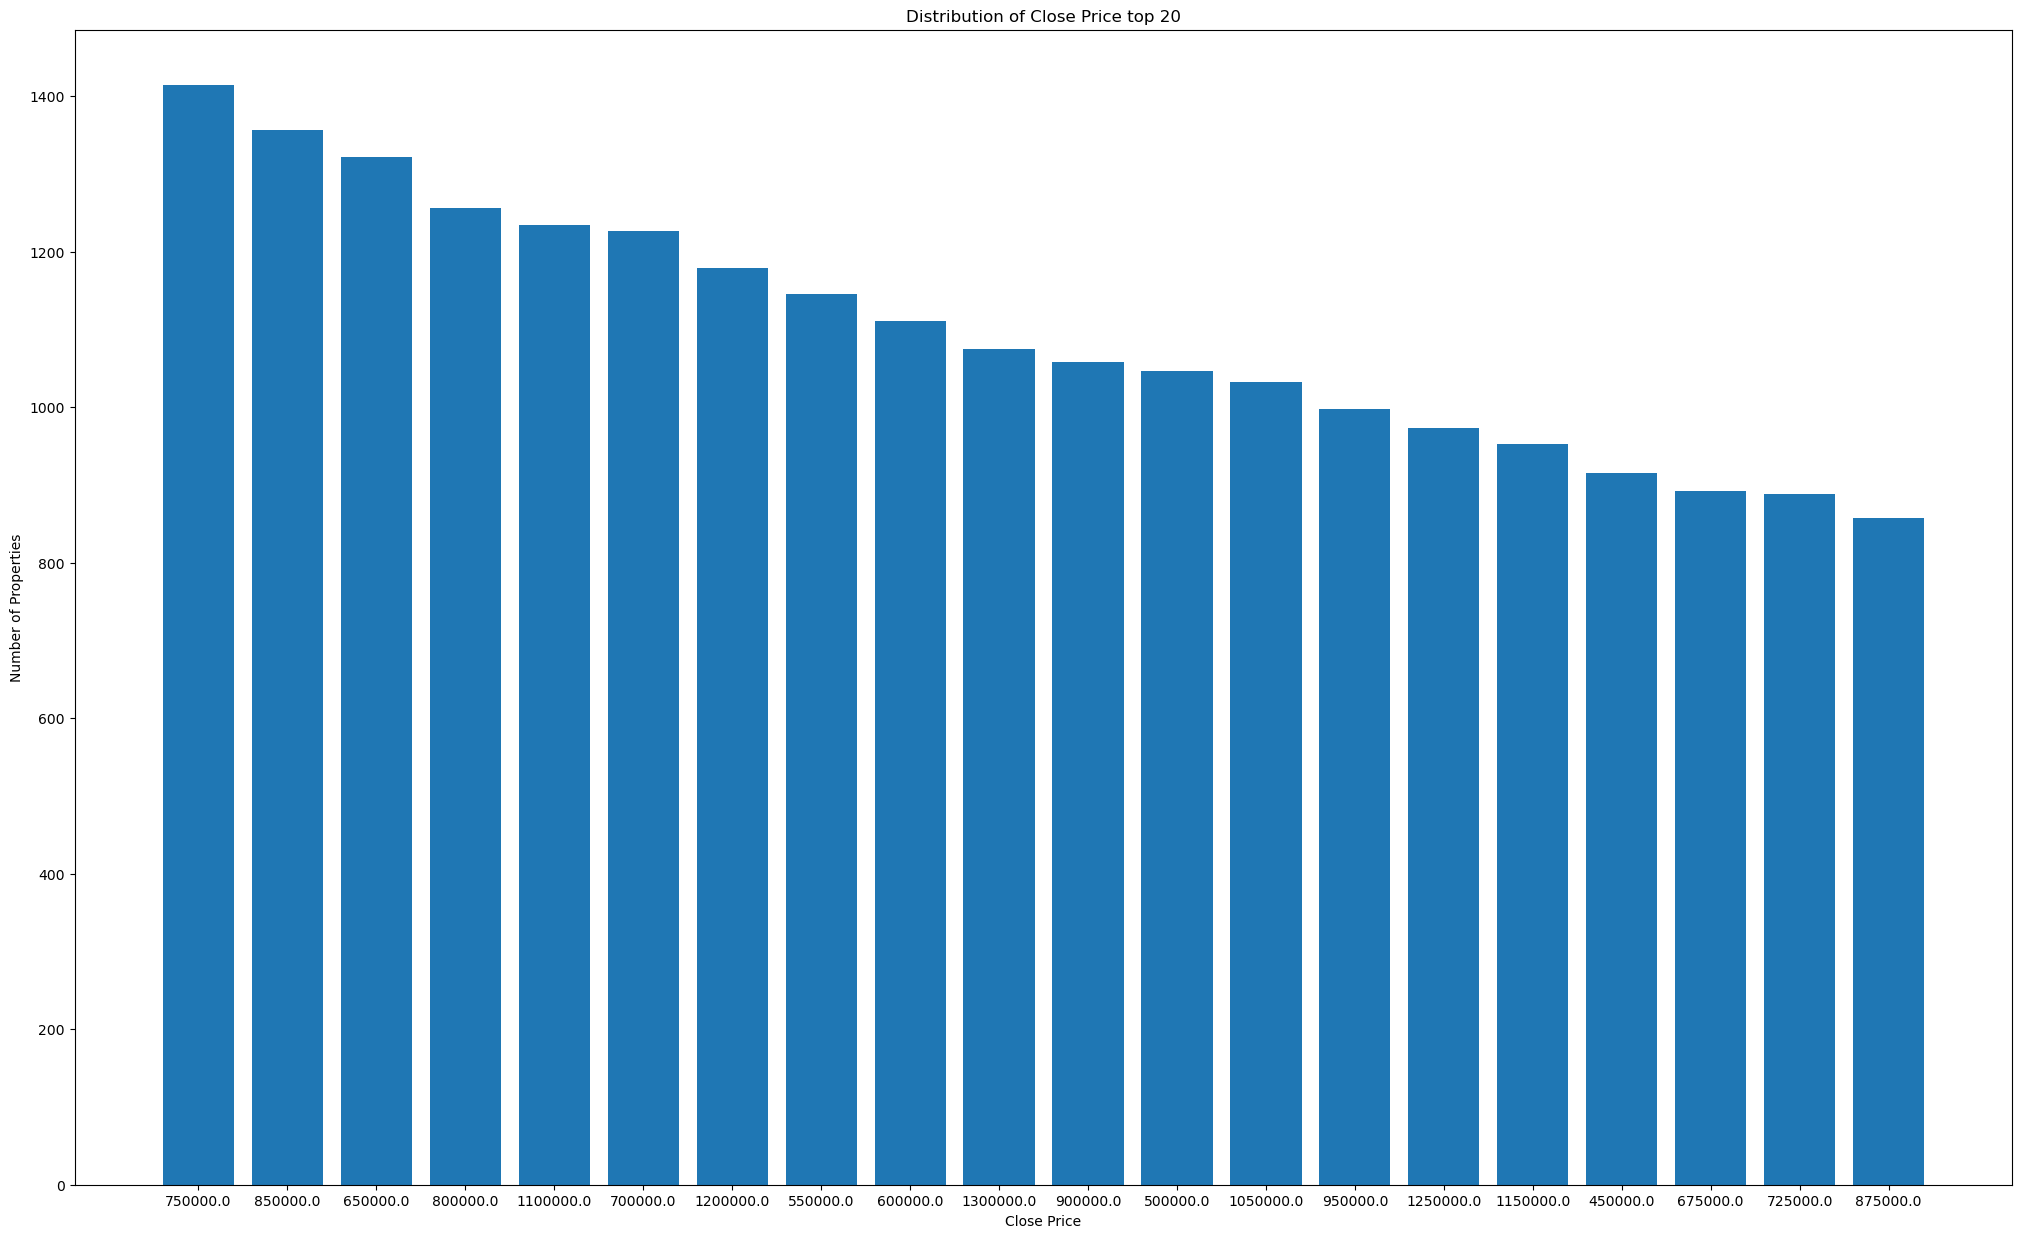

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["ClosePrice"].value_counts().head(20).index.astype(str),dataset_total_last6_r["ClosePrice"].value_counts().head(20).values)
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price top 20")
plt.show()

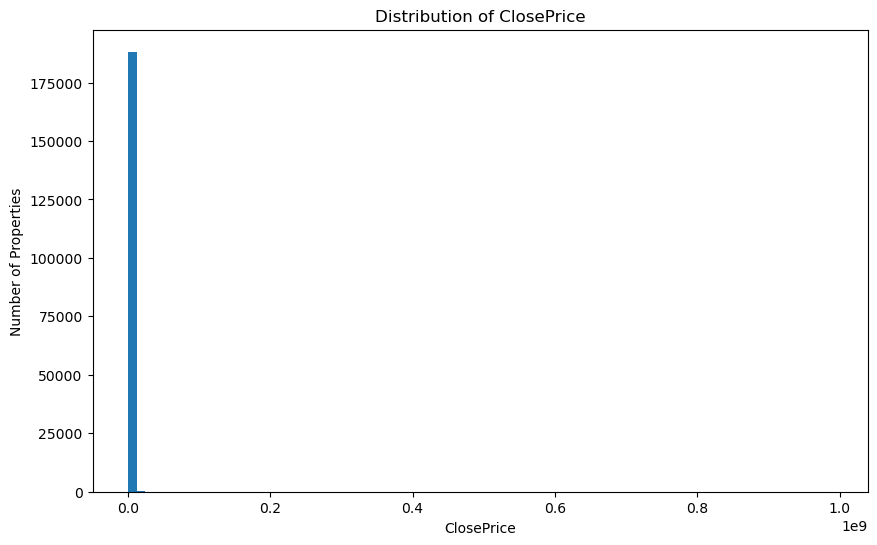

In [11]:
upper = dataset_total_last6_r["ClosePrice"]
data = dataset_total_last6_r[ dataset_total_last6_r["ClosePrice"] <= upper]["ClosePrice"]
plt.figure(figsize=(10,6))
plt.hist(data, bins=80)
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.title("Distribution of ClosePrice")
plt.show()

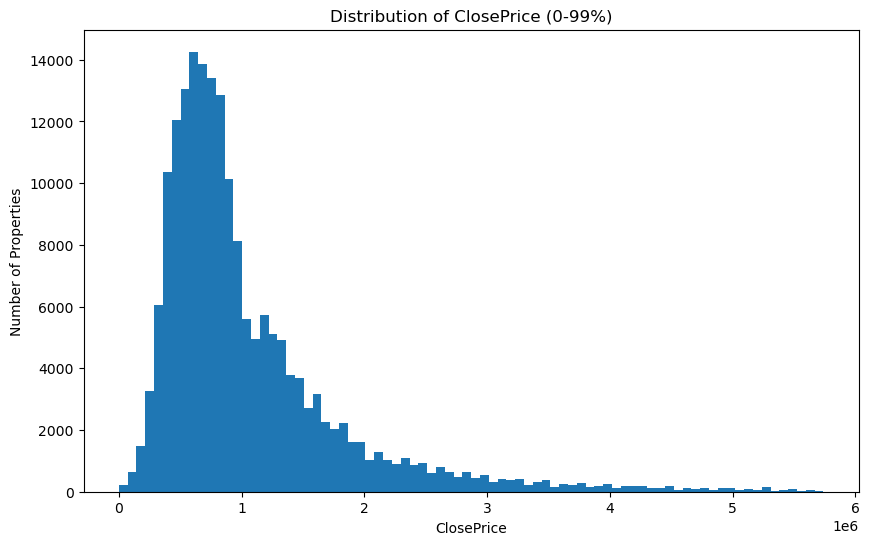

In [12]:
upper = dataset_total_last6_r["ClosePrice"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["ClosePrice"] <= upper]["ClosePrice"]
plt.figure(figsize=(10,6))
plt.hist(data, bins=80)
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.title("Distribution of ClosePrice (0-99%)")
plt.show()

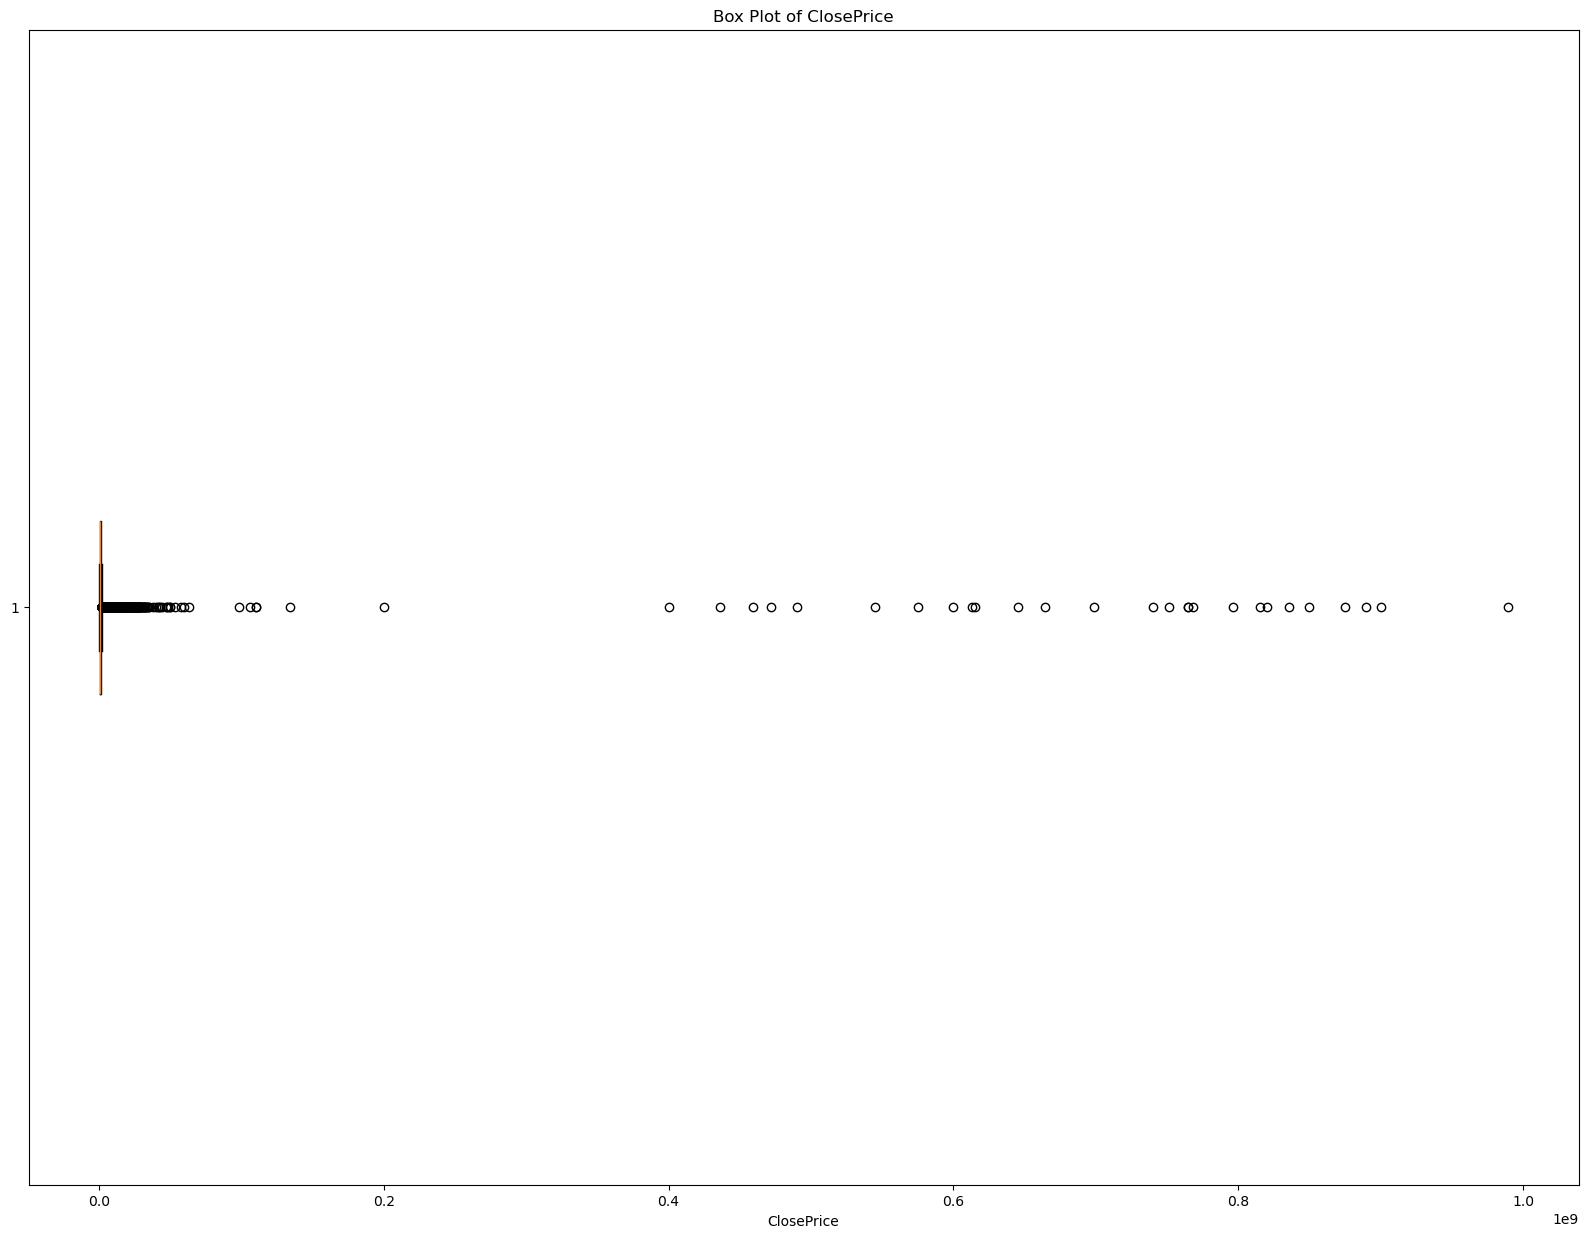

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["ClosePrice"].dropna(), vert=False)

plt.title("Box Plot of ClosePrice")
plt.xlabel("ClosePrice")
plt.show()

## 2. LivingArea 

**Definition**: The total livable area within the structure.

**Distribution Analysis:**

**LivingArea** contains very few missing values (188,442 out of 188,550 records are available, with only 108 missing values, approximately **0.05%**). The histogram (excluding the top 1% of extreme values) shows that the distribution of **LivingArea** is positively skewed. Most properties have relatively moderate living areas, with the majority concentrated between approximately **500 and 2,600 sq ft**. The frequency gradually decreases as the living area increases, resulting in a long right tail. The most common living area is **1,200 sq ft**, which appears in **667** properties, followed by **1,440 sq ft** (638 properties), **1,300 sq ft** (445 properties), and **1,344 sq ft** (439 properties).

The box plot further confirms that **LivingArea** is positively skewed and contains numerous upper-end outliers. While most properties fall within a relatively compact range, a small number of homes have exceptionally large living areas, extending the upper tail of the distribution. These observations are likely associated with luxury or specialty properties rather than data quality issues and are therefore retained during the exploratory data analysis stage.

<span style="color:red">Additionally, 86 records contain LivingArea values of 0, which are not valid physical measurements. These entries are treated as implicitly missing values and are addressed in the preprocessing stage.</span>

In [20]:
dataset_total_last6_r["LivingArea"].value_counts()

LivingArea
1200.0     667
1440.0     638
1300.0     445
1344.0     439
1400.0     427
          ... 
5227.0       1
7134.0       1
9170.0       1
5207.0       1
23314.0      1
Name: count, Length: 6174, dtype: int64

In [18]:
dataset_total_last6_r["LivingArea"].dropna().describe()

count    188442.000000
mean       1879.079620
std        1010.068479
min           0.000000
25%        1256.000000
50%        1658.500000
75%        2243.000000
max       84500.000000
Name: LivingArea, dtype: float64

In [19]:
sum(dataset_total_last6_r["LivingArea"] == 0)

86

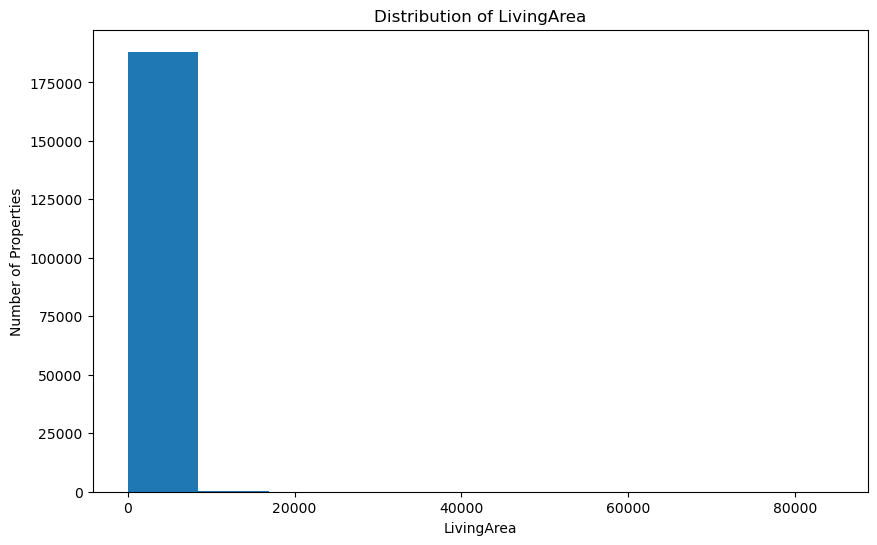

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["LivingArea"])
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea")
plt.show()

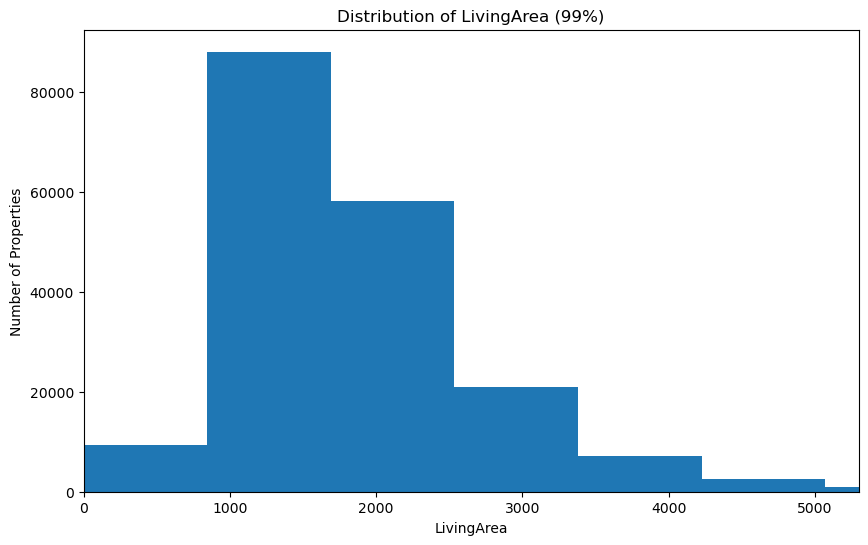

In [22]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["LivingArea"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["LivingArea"], bins=100)
plt.xlim(0, upper)
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea (99%)")
plt.show()

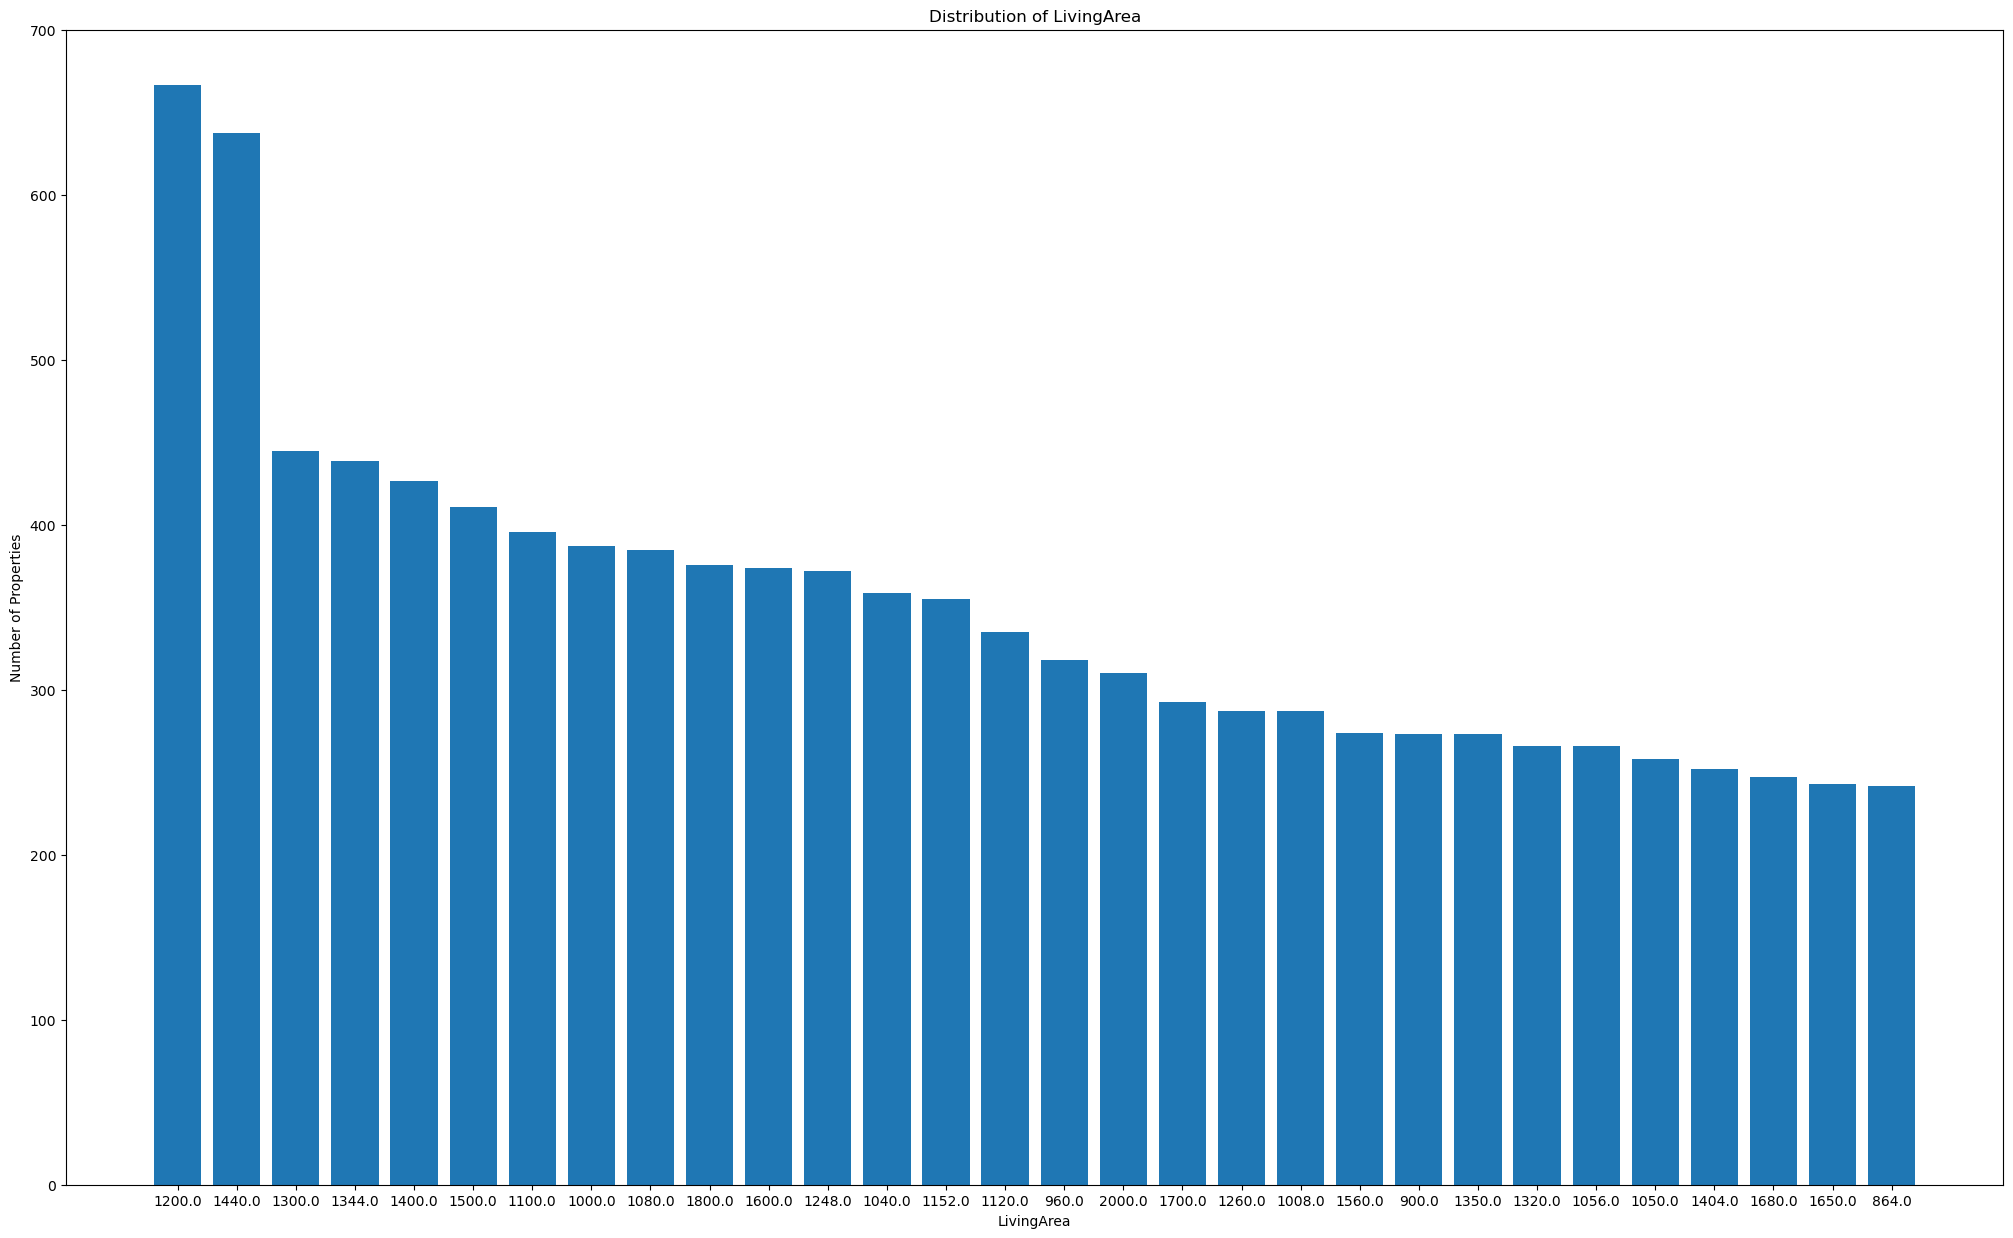

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["LivingArea"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["LivingArea"].value_counts().head(30).values)
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea")
plt.show()

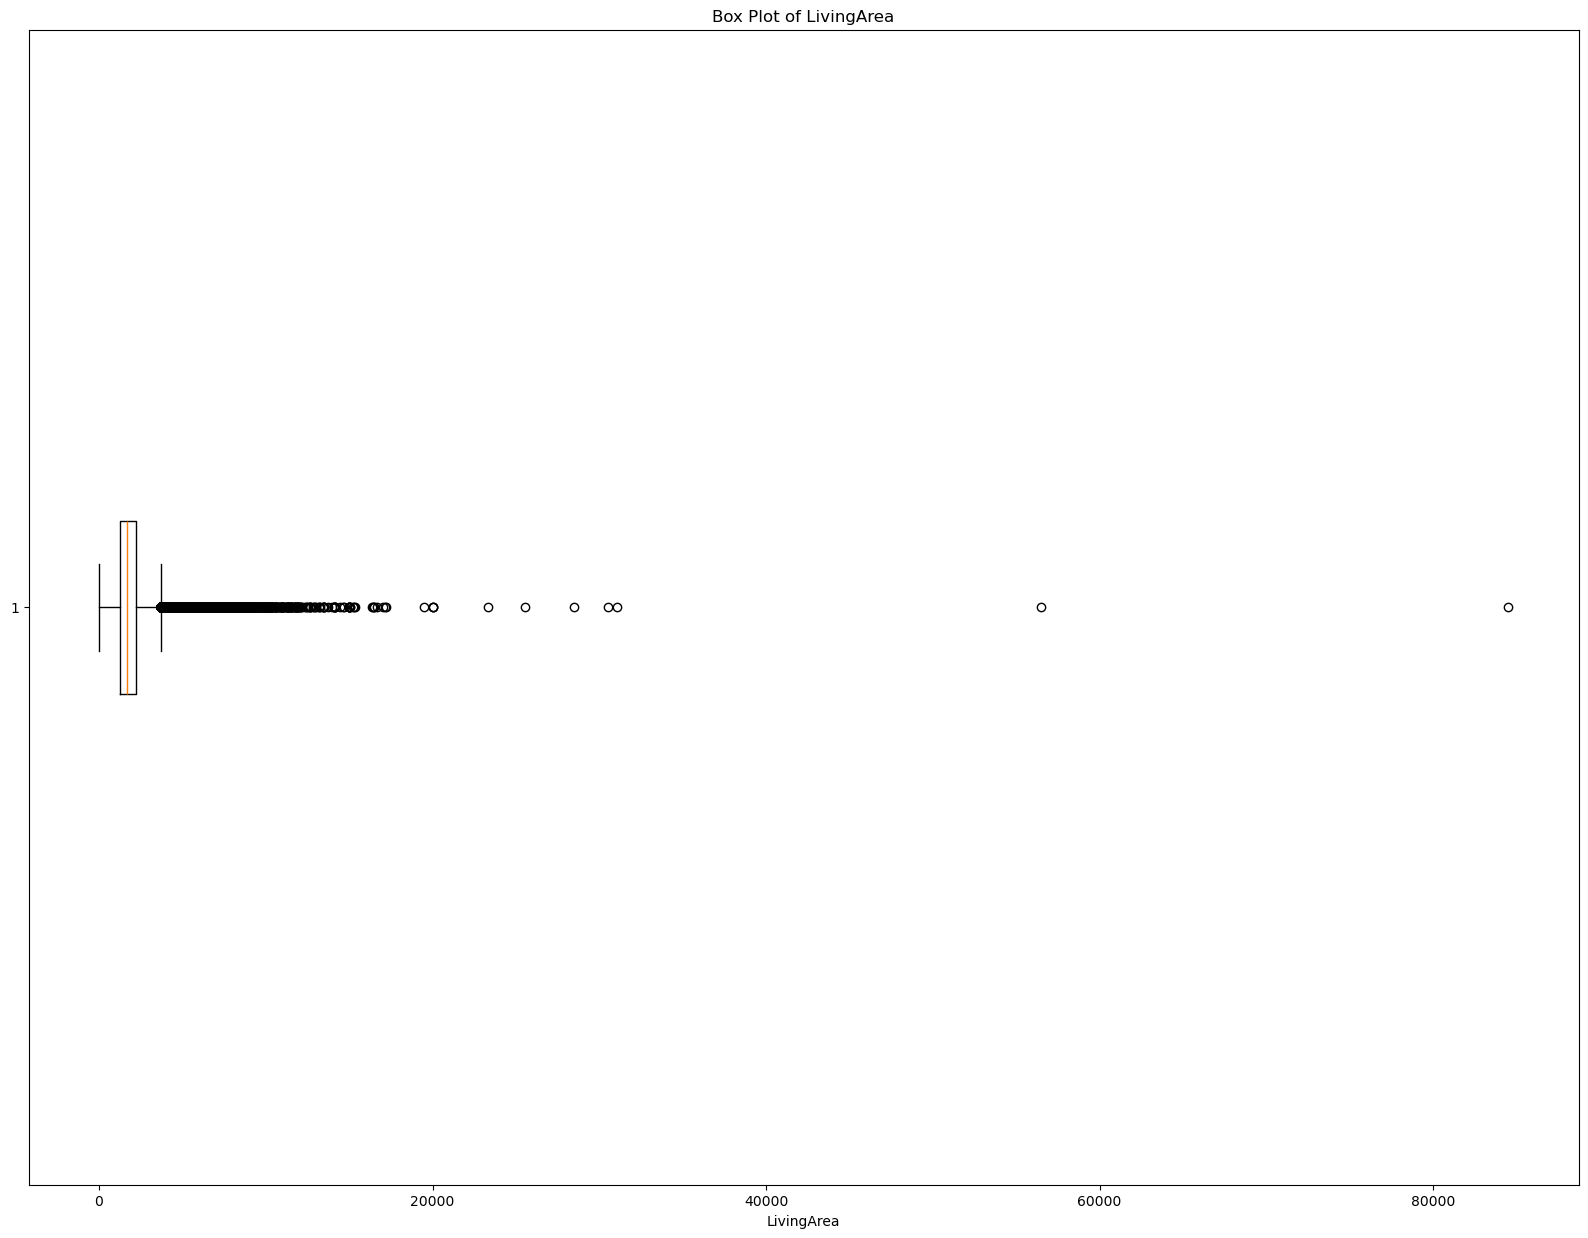

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["LivingArea"].dropna(), vert=False)

plt.title("Box Plot of LivingArea")
plt.xlabel("LivingArea")
plt.show()

# 3. Bathrooms

**Definition of BathroomsTotalInteger**: The simple sum of the number of bathrooms. For example for a property with two Full Bathrooms and one Half Bathroom, the Bathrooms Total Integer will be 3. Expressing this example as 2.5, you will need to use a non-standard field name. Decimal based bathrooms are not recommended but possible via the Dictionary's extensibility.


**Distribution Analysis:**

The dataset contains a very small number of missing values in the Bathroom variable (3 records). The distribution of bathroom counts is highly concentrated between 1 and 4, indicating a strong central tendency in residential properties. The most common values are 2 and 3 bathrooms, with frequencies of 81,401 and 63,125 respectively. In addition, 156 records have Bathroom values recorded as 0, which are likely not valid physical measurements and are therefore treated as implicitly missing values during preprocessing.

The boxplot shows that the majority of values are concentrated within the interquartile range, with only a small number of observations exceeding the upper whisker. These points can be considered high-end outliers in the distribution.

In [25]:
dataset_total_last6_r["BathroomsTotalInteger"].value_counts()

BathroomsTotalInteger
2.0     81401
3.0     63125
1.0     20546
4.0     14454
5.0      5405
6.0      2075
7.0       763
8.0       312
0.0       156
9.0       136
10.0       69
11.0       39
12.0       15
13.0       11
14.0        7
15.0        6
16.0        2
18.0        2
20.0        1
31.0        1
17.0        1
27.0        1
35.0        1
23.0        1
21.0        1
22.0        1
Name: count, dtype: int64

In [26]:
dataset_total_last6_r["BathroomsTotalInteger"].dropna().describe()

count    188532.000000
mean          2.551127
std           1.083427
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          35.000000
Name: BathroomsTotalInteger, dtype: float64

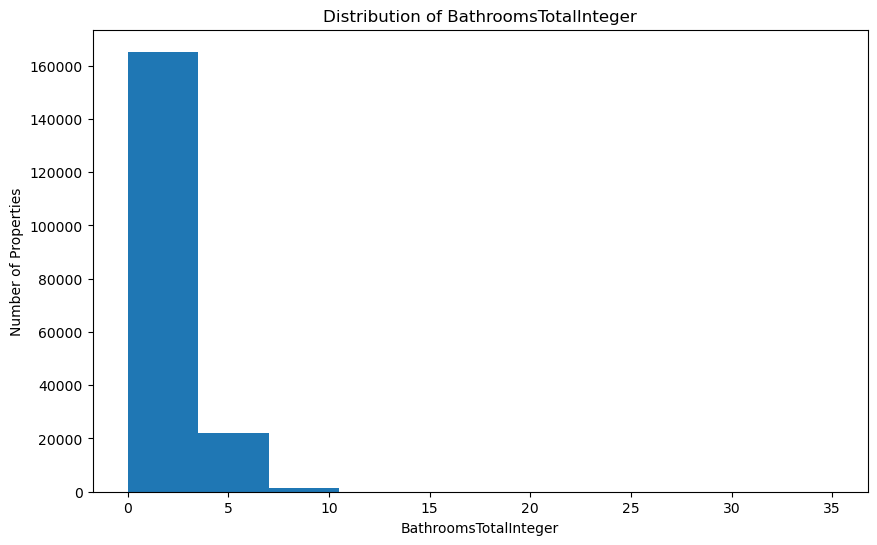

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["BathroomsTotalInteger"])
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger")
plt.show()

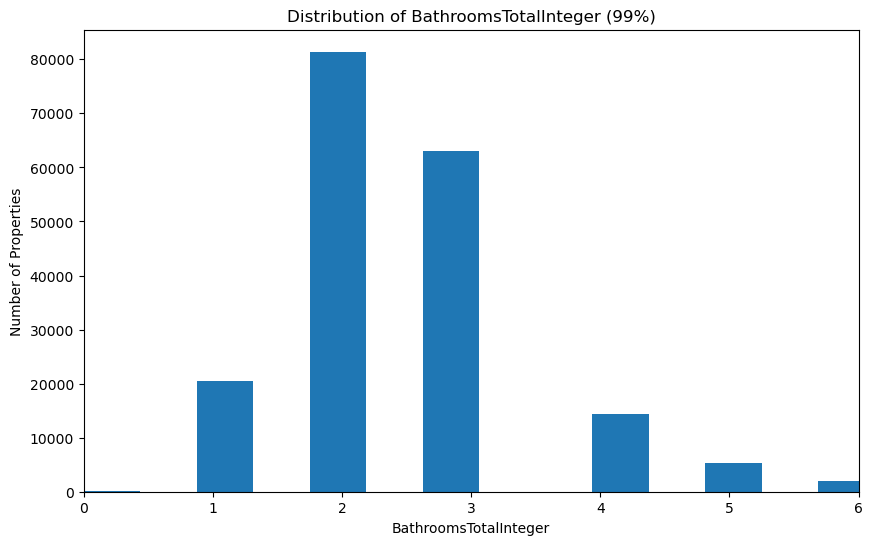

In [28]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["BathroomsTotalInteger"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["BathroomsTotalInteger"], bins=80)
plt.xlim(0, upper)
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger (99%)")
plt.show()

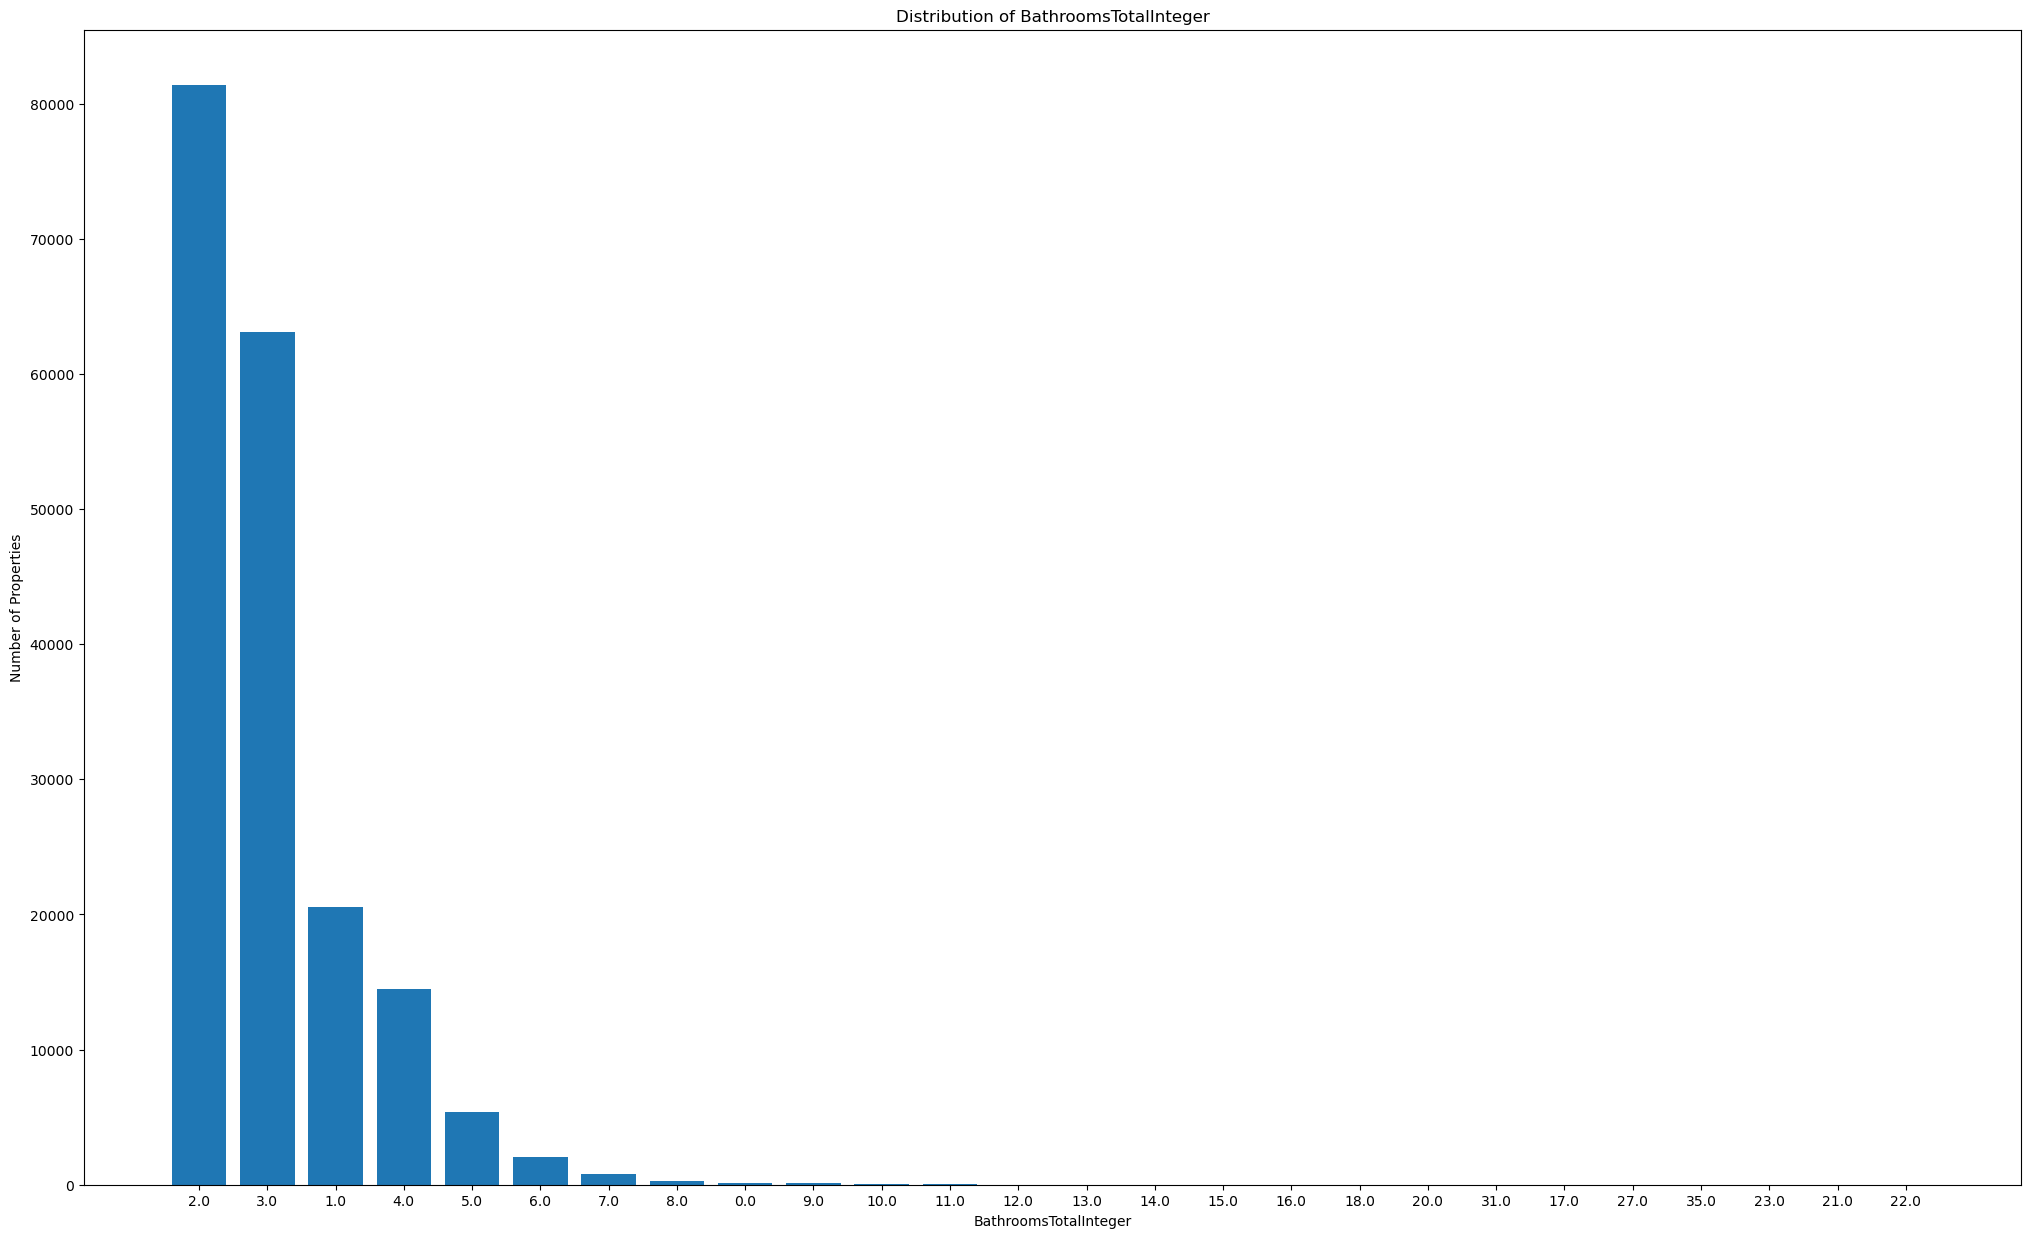

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["BathroomsTotalInteger"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["BathroomsTotalInteger"].value_counts().head(30).values)
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger")
plt.show()

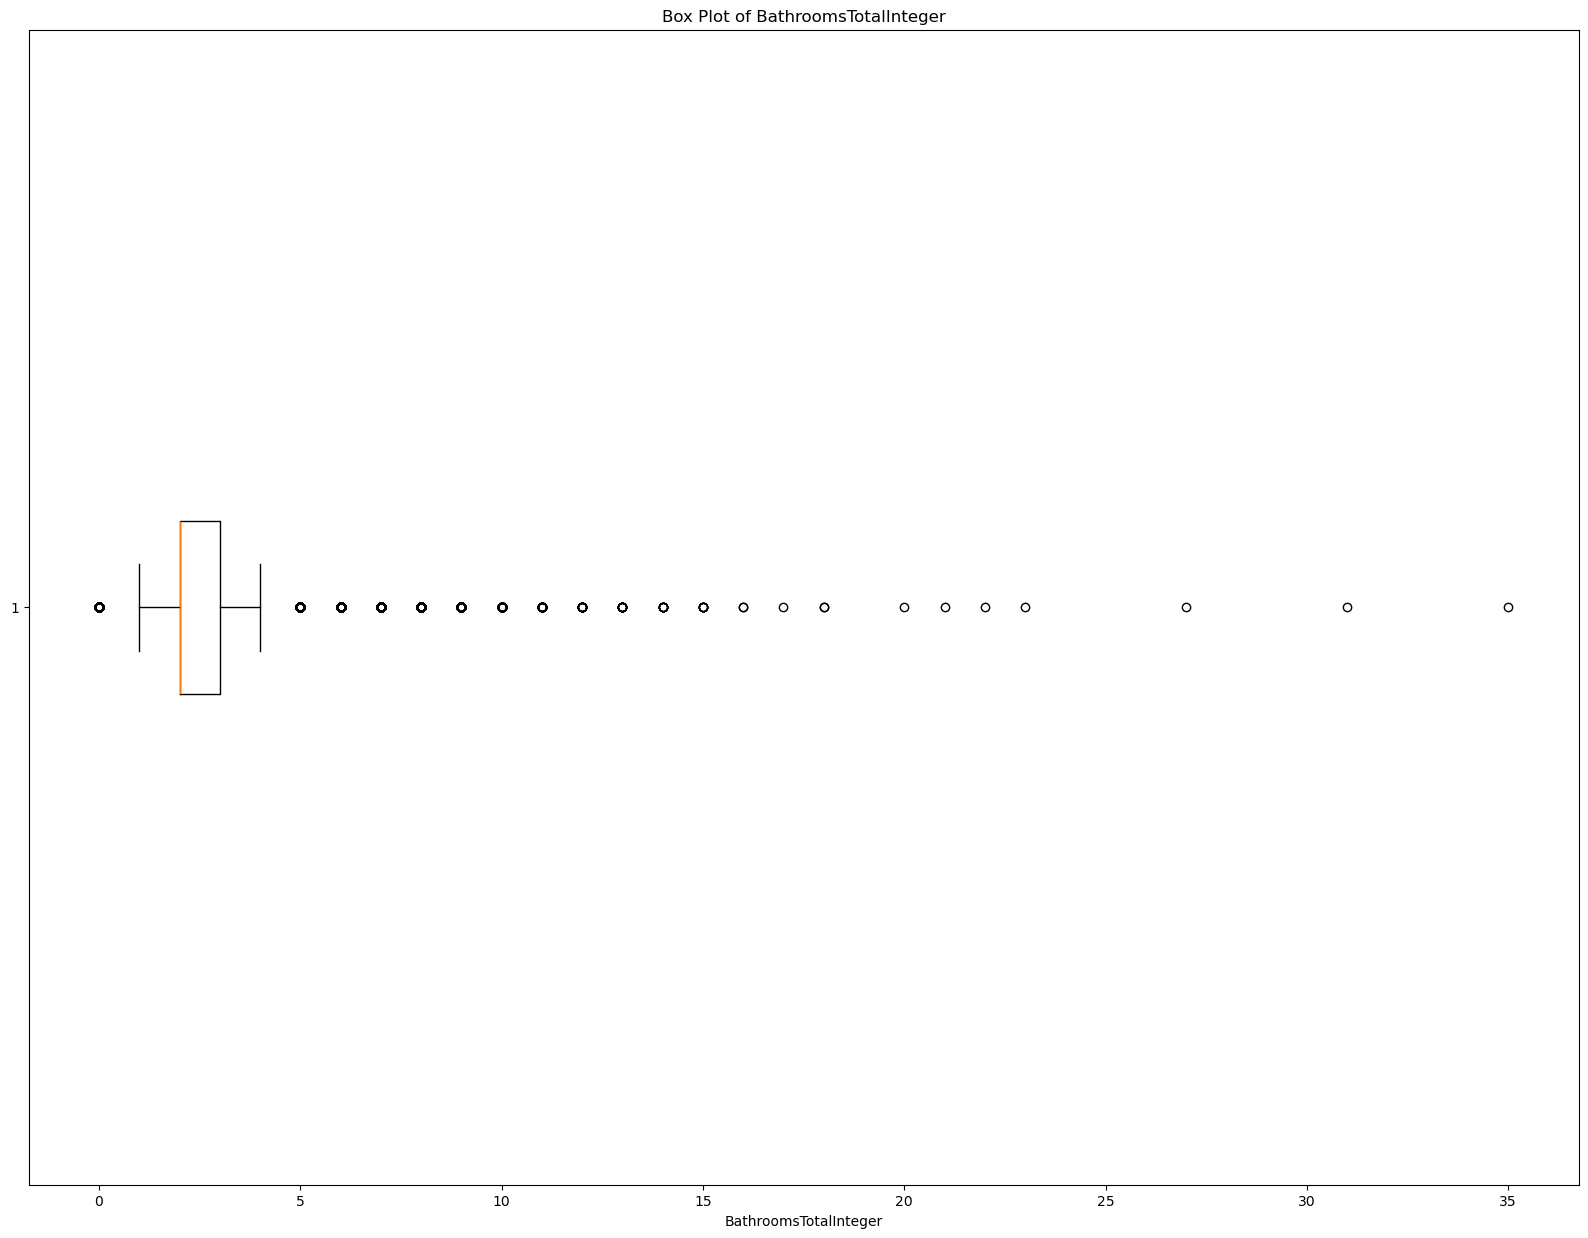

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["BathroomsTotalInteger"].dropna(), vert=False)

plt.title("Box Plot of BathroomsTotalInteger")
plt.xlabel("BathroomsTotalInteger")
plt.show()

## 4. Bedrooms

**Definition of BedroomsTotal**: The total number of bedrooms in the dwelling.

**Distribution Analysis:**

The dataset contains a very small number of missing values in the Bathroom variable (5 records). The distribution of bedrooms is concentrated between 1 and 5, with the most common values being $3$, $4$, and $2$ bedrooms, occurring $74,336$, $50,654$, and $38,096$ times respectively.

The boxplot shows that most values are concentrated within the interquartile range, while a small number of observations lie outside the whiskers on both the lower and upper ends, indicating the presence of outliers in the distribution.

In [31]:
dataset_total_last6_r["BedroomsTotal"].value_counts()

BedroomsTotal
3.0     74336
4.0     50654
2.0     38096
5.0     15134
1.0      6183
6.0      2779
7.0       562
0.0       506
8.0       174
9.0        55
10.0       38
12.0        7
11.0        7
13.0        4
16.0        4
14.0        1
15.0        1
19.0        1
20.0        1
22.0        1
24.0        1
Name: count, dtype: int64

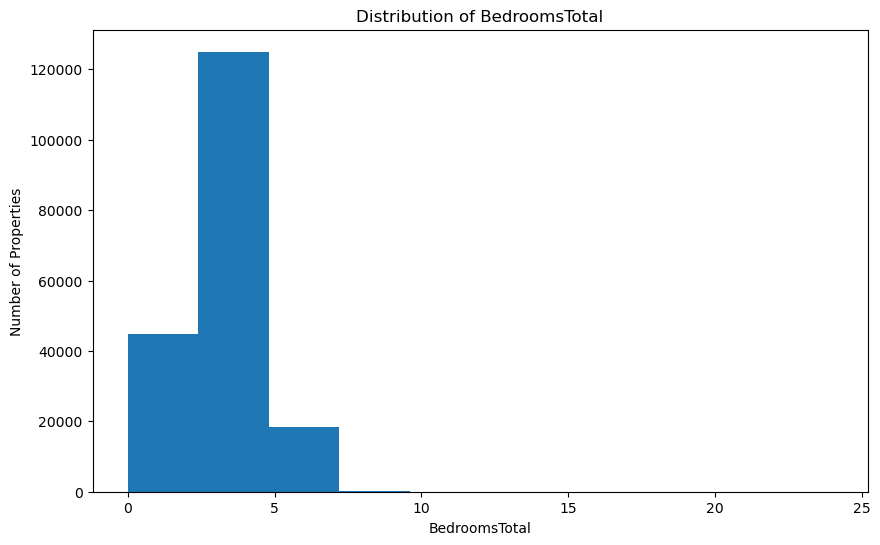

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["BedroomsTotal"])
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal")
plt.show()

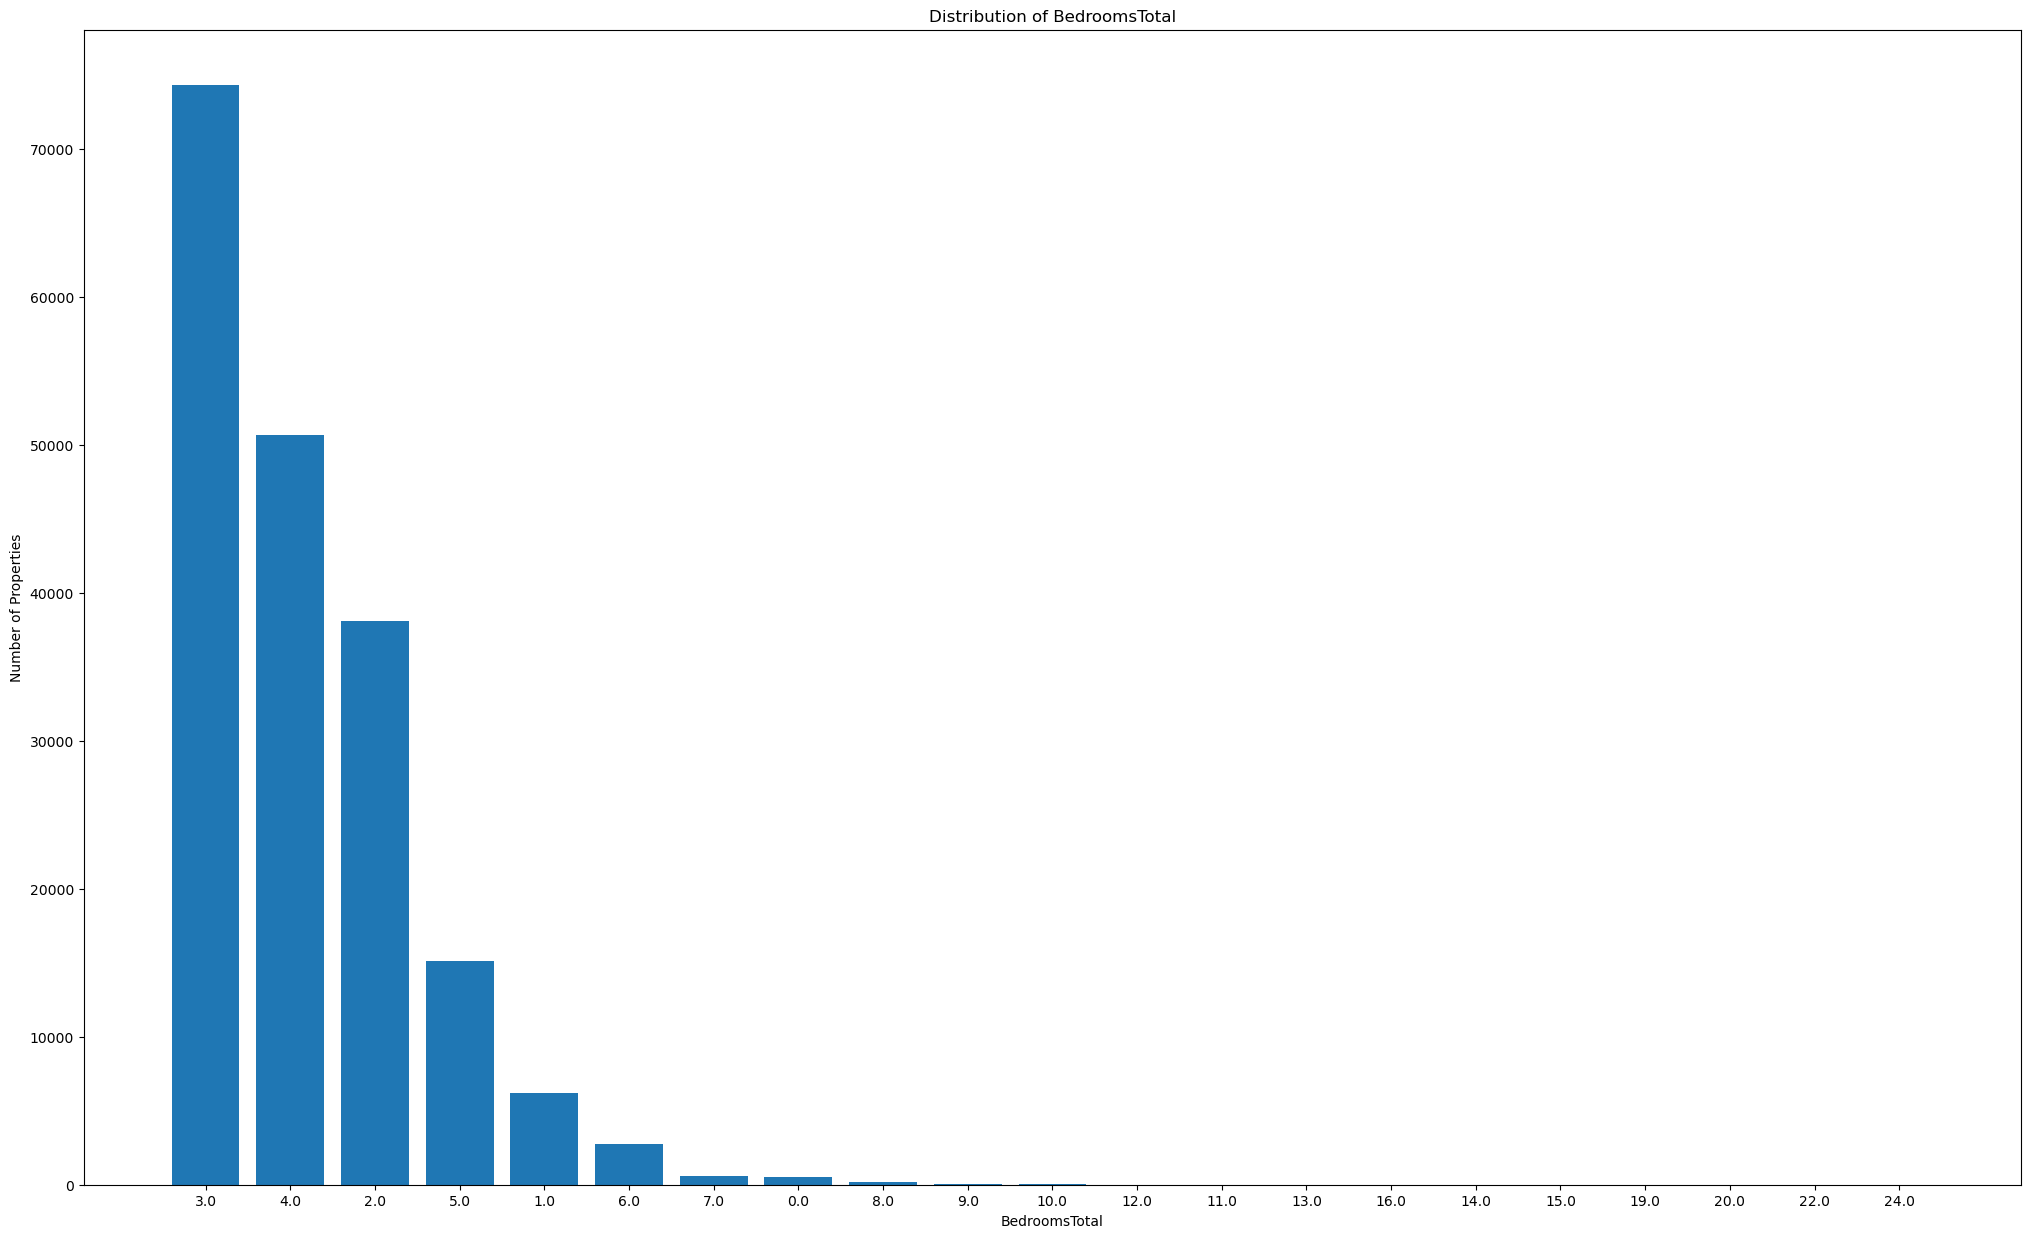

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["BedroomsTotal"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["BedroomsTotal"].value_counts().head(30).values)
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal")
plt.show()

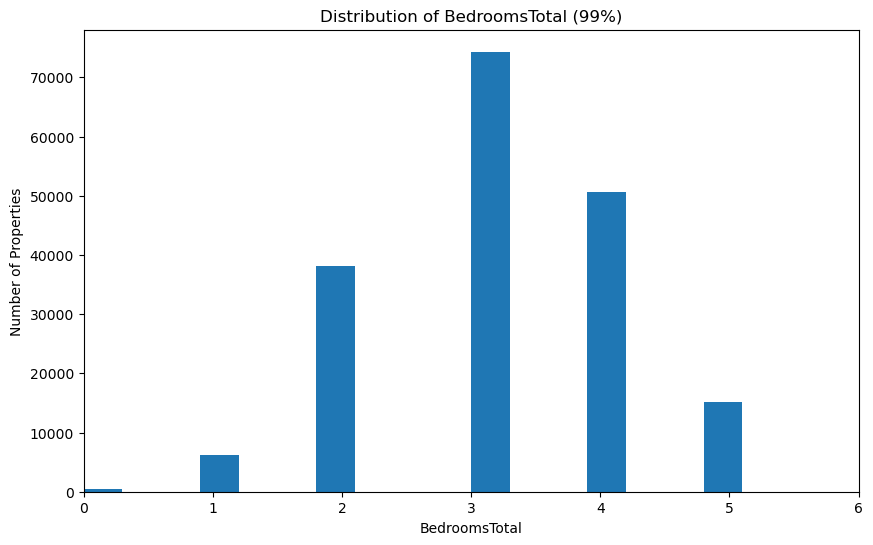

In [34]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["BedroomsTotal"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["BedroomsTotal"], bins=80)
plt.xlim(0, upper)
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal (99%)")
plt.show()

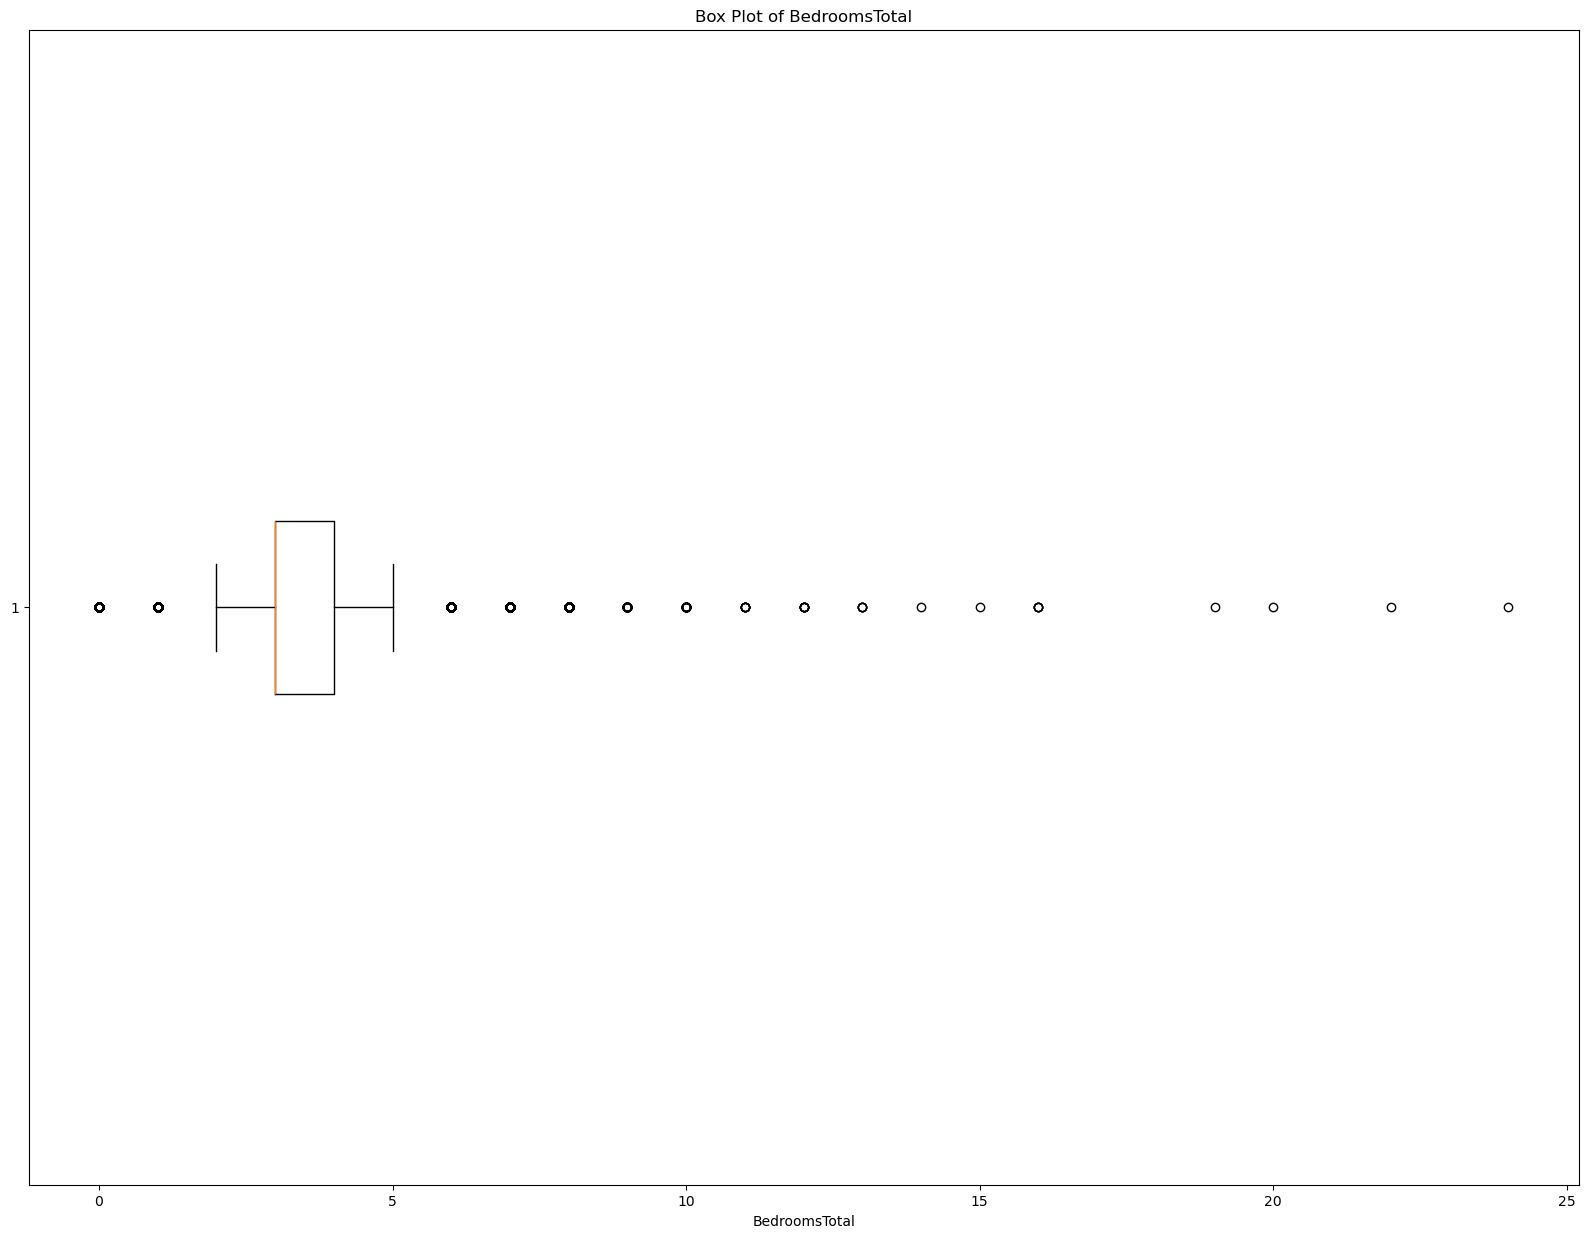

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["BedroomsTotal"].dropna(), vert=False)

plt.title("Box Plot of BedroomsTotal")
plt.xlabel("BedroomsTotal")
plt.show()

## 5. LotSize

**Definition of LotSizeArea**: The total area of the lot. See Lot Size Units for the units of measurement (Square Feet, Square Meters, Acres, etc.).

**Definition of LotSizeDimensions**: The dimensions of the lot minimally represented as length and width (i.e. $250 x 180$) or a measurement of all sides of the polygon representing the property lines of the property. i.e. $30 x 50 x 120 x 60 x 22$.

**Definition of LotSizeSquareFeet**: The total square footage of the lot. This field is related to the Lot Size Area and Lot Size Units and must be in sync with the values represented in those fields. Lot Size Source also applies to this field when used.


<span style="color:red"> **Since the dataset does not provide the feature “Lot Size Units”, the “LotSizeArea” variable cannot be reliably used due to inconsistent unit definitions across records.** </span>

**Distribution Analysis:**

**LotSizeDimensions:**

The LotSizeDimensions feature contains a significant number of missing values ($9,508$ out of $188,550$ records). The most common value is "$50$ x $135$", appearing $67$ times, which represents a typical lot dimension format. However, there are also $22$ records with a value of "$0$", which is not a valid dimension and is treated as a missing or erroneous entry. In addition, several irregular values (e.g., "$7405$") do not follow the expected "length x width" format, indicating inconsistent data formatting. Due to the high proportion of missing and malformed entries, this feature requires careful preprocessing and standardization before it can be used reliably in modeling.


**LotSizeSquareFeet:** 

The LotSizeSquareFeet feature also contains a large number of missing or invalid values, with $175,666$ records affected. The distribution is highly concentrated between approximately $3,000$ and $12,000$ square feet. The most frequent valid values include $6,000$ and $7,405$ square feet (corresponding to $2,773$ and $2,080$ occurrences respectively). However, the presence of zero values is not valid, as lot size cannot be zero, and these are treated as missing entries.

The boxplot further indicates a highly right-skewed distribution with numerous extreme outliers. The large discrepancy between the mean ($44168.19$ sq ft) and median ($7,100$ sq ft), together with a maximum value of $9.1$ billion sq ft, suggests severe data quality issues and the presence of extreme outliers that heavily distort the distribution.

In [52]:
dataset_total_last6_r["LotSizeArea"].describe()

count    1.756660e+05
mean     4.416819e+04
std      2.896881e+06
min      0.000000e+00
25%      5.002000e+03
50%      7.100000e+03
75%      1.122975e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

In [53]:
dataset_total_last6_r["LotSizeArea"].value_counts()

LotSizeArea
0.0         3400
7405.0      2773
6000.0      2080
6098.0      1771
6534.0      1670
            ... 
16321.0        1
19052.0        1
205790.0       1
2214.0         1
30457.0        1
Name: count, Length: 30159, dtype: int64

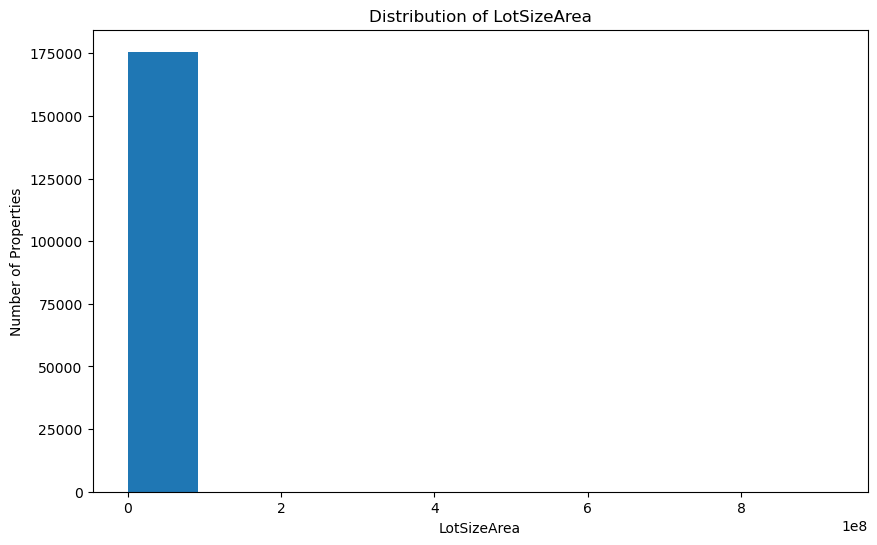

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["LotSizeArea"])
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea")
plt.show()

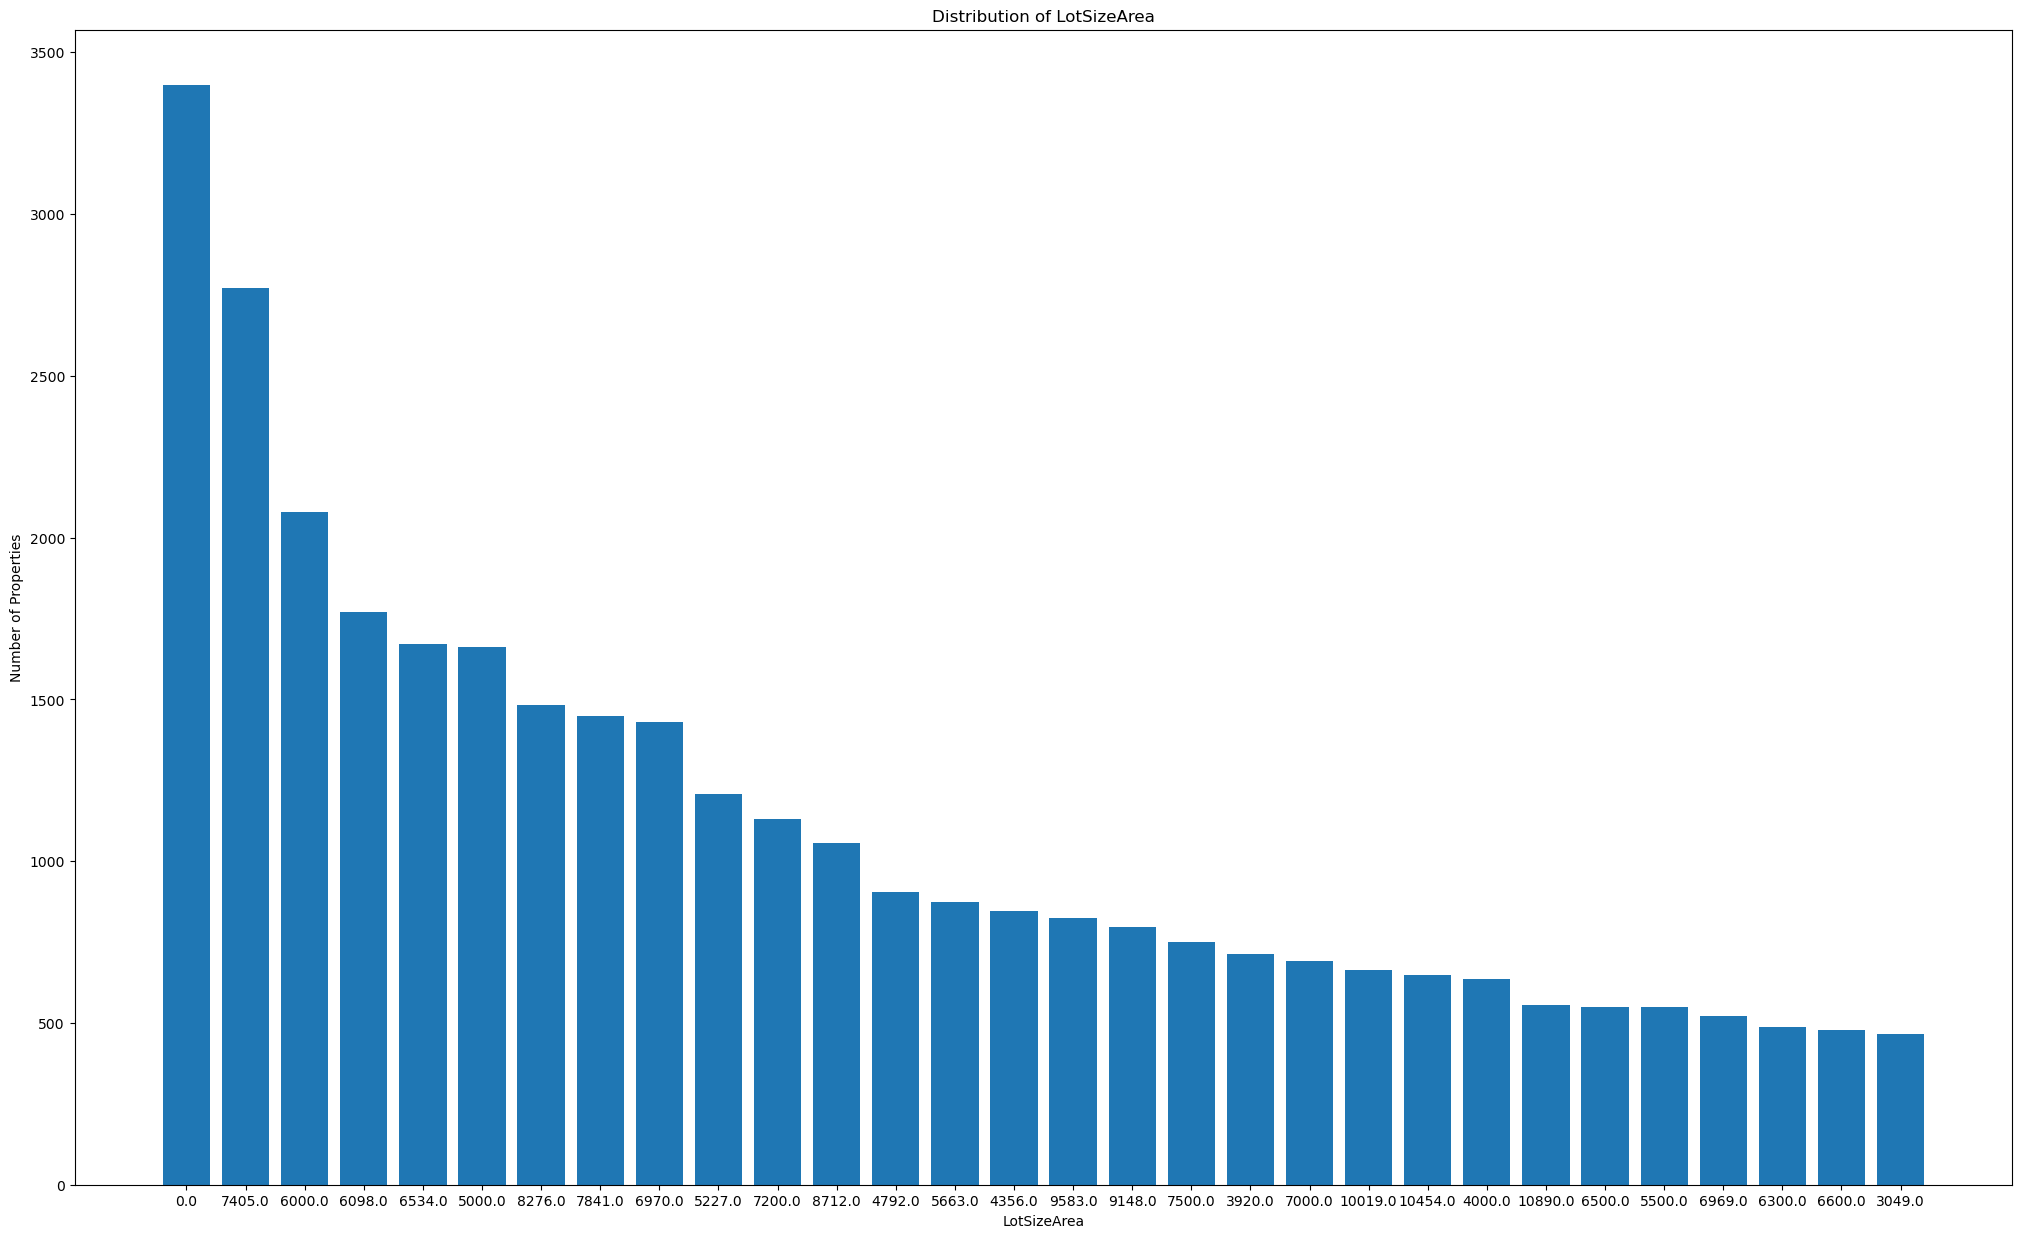

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["LotSizeArea"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["LotSizeArea"].value_counts().head(30).values)
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea")
plt.show()

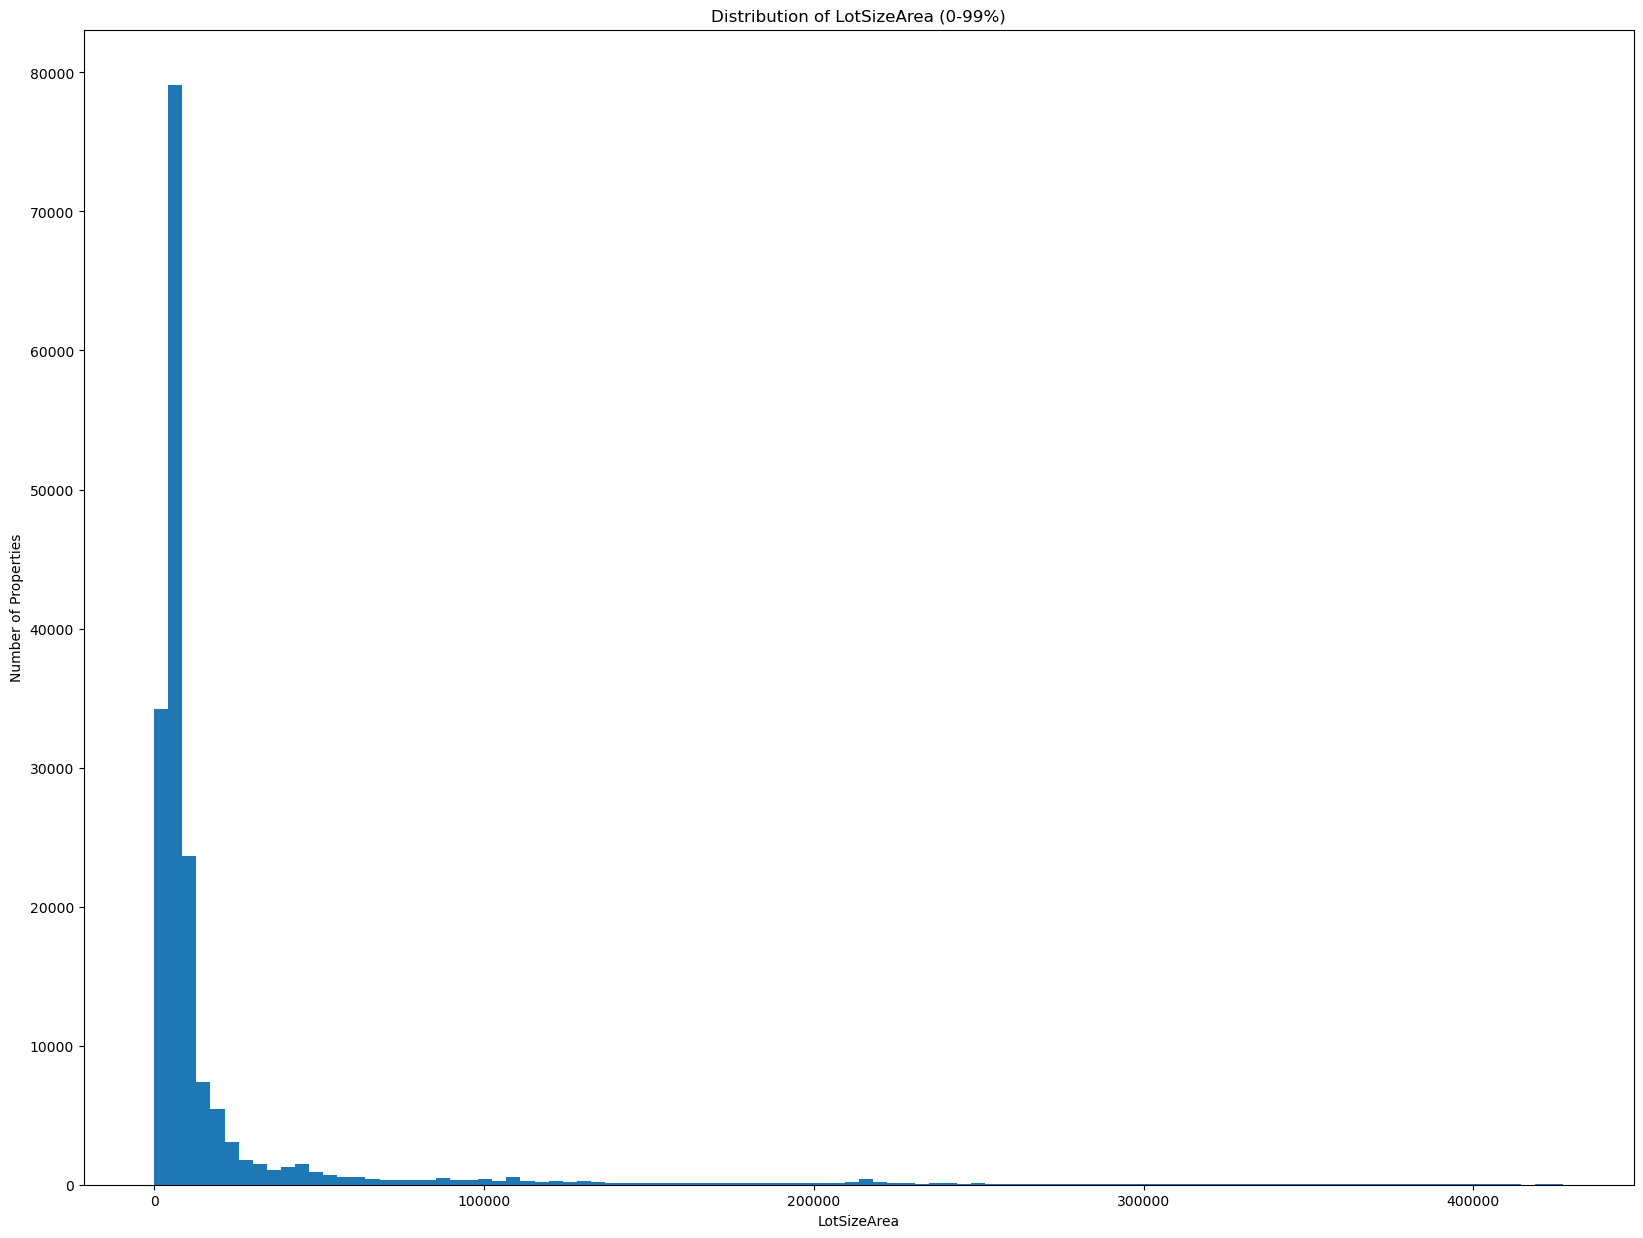

In [56]:
upper = dataset_total_last6_r["LotSizeArea"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["LotSizeArea"] <= upper]["LotSizeArea"]
plt.figure(figsize=(20,15))
plt.hist(data, bins=100)
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea (0-99%)")
plt.show()

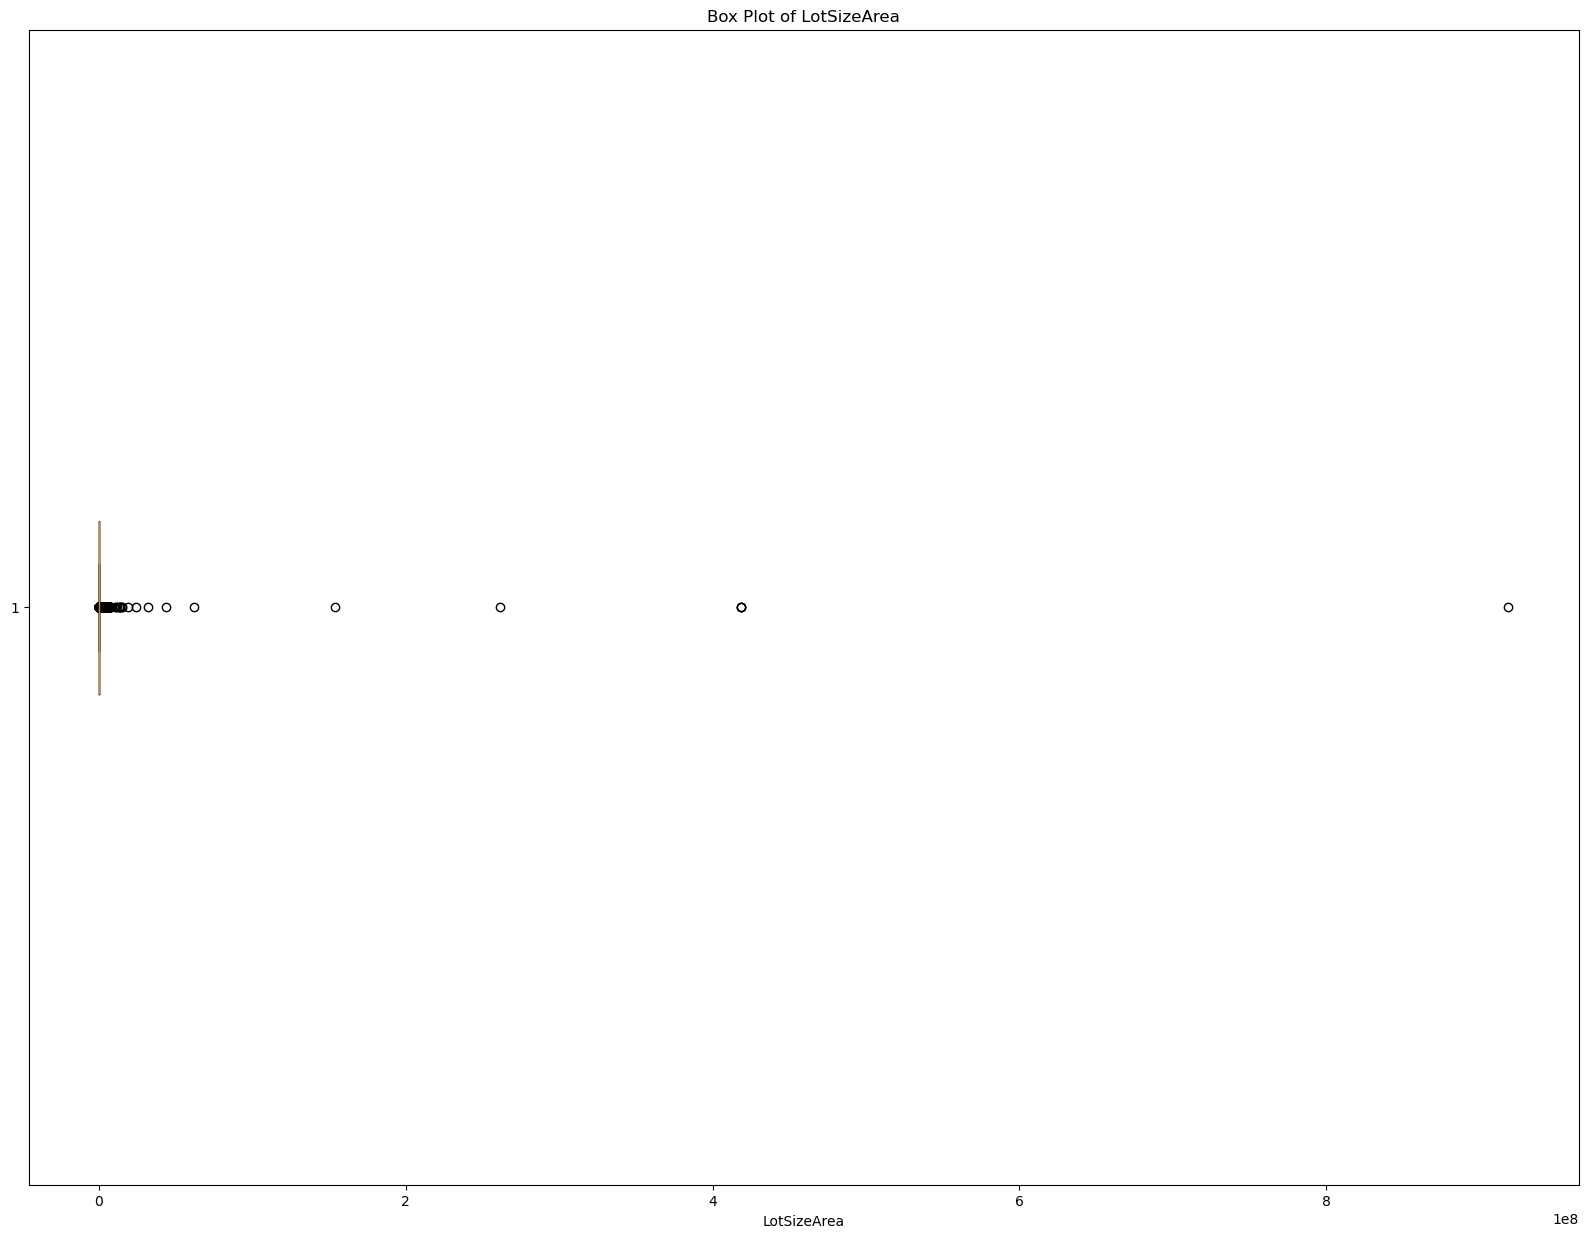

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["LotSizeArea"].dropna(), vert=False)

plt.title("Box Plot of LotSizeArea")
plt.xlabel("LotSizeArea")
plt.show()

LotSizeDimensions:The dimensions of the lot minimally represented as length and width (i.e. 250 x 180) or a measurement of all sides of the polygon representing the property lines of the property. i.e. 30 x 50 x 120 x 60 x 22.

In [58]:
dataset_total_last6_r["LotSizeDimensions"].value_counts()

LotSizeDimensions
50x135             176
50x100             118
50x130             107
50x120              99
50x150              98
                  ... 
45x145               1
173x183x162x129      1
62x119               1
40x98                1
71.57                1
Name: count, Length: 5550, dtype: int64

In [59]:
dataset_total_last6_r["LotSizeDimensions"].describe()

count       9508
unique      5550
top       50x135
freq         176
Name: LotSizeDimensions, dtype: object

In [60]:
sum(dataset_total_last6_r["LotSizeDimensions"]=="0")

22

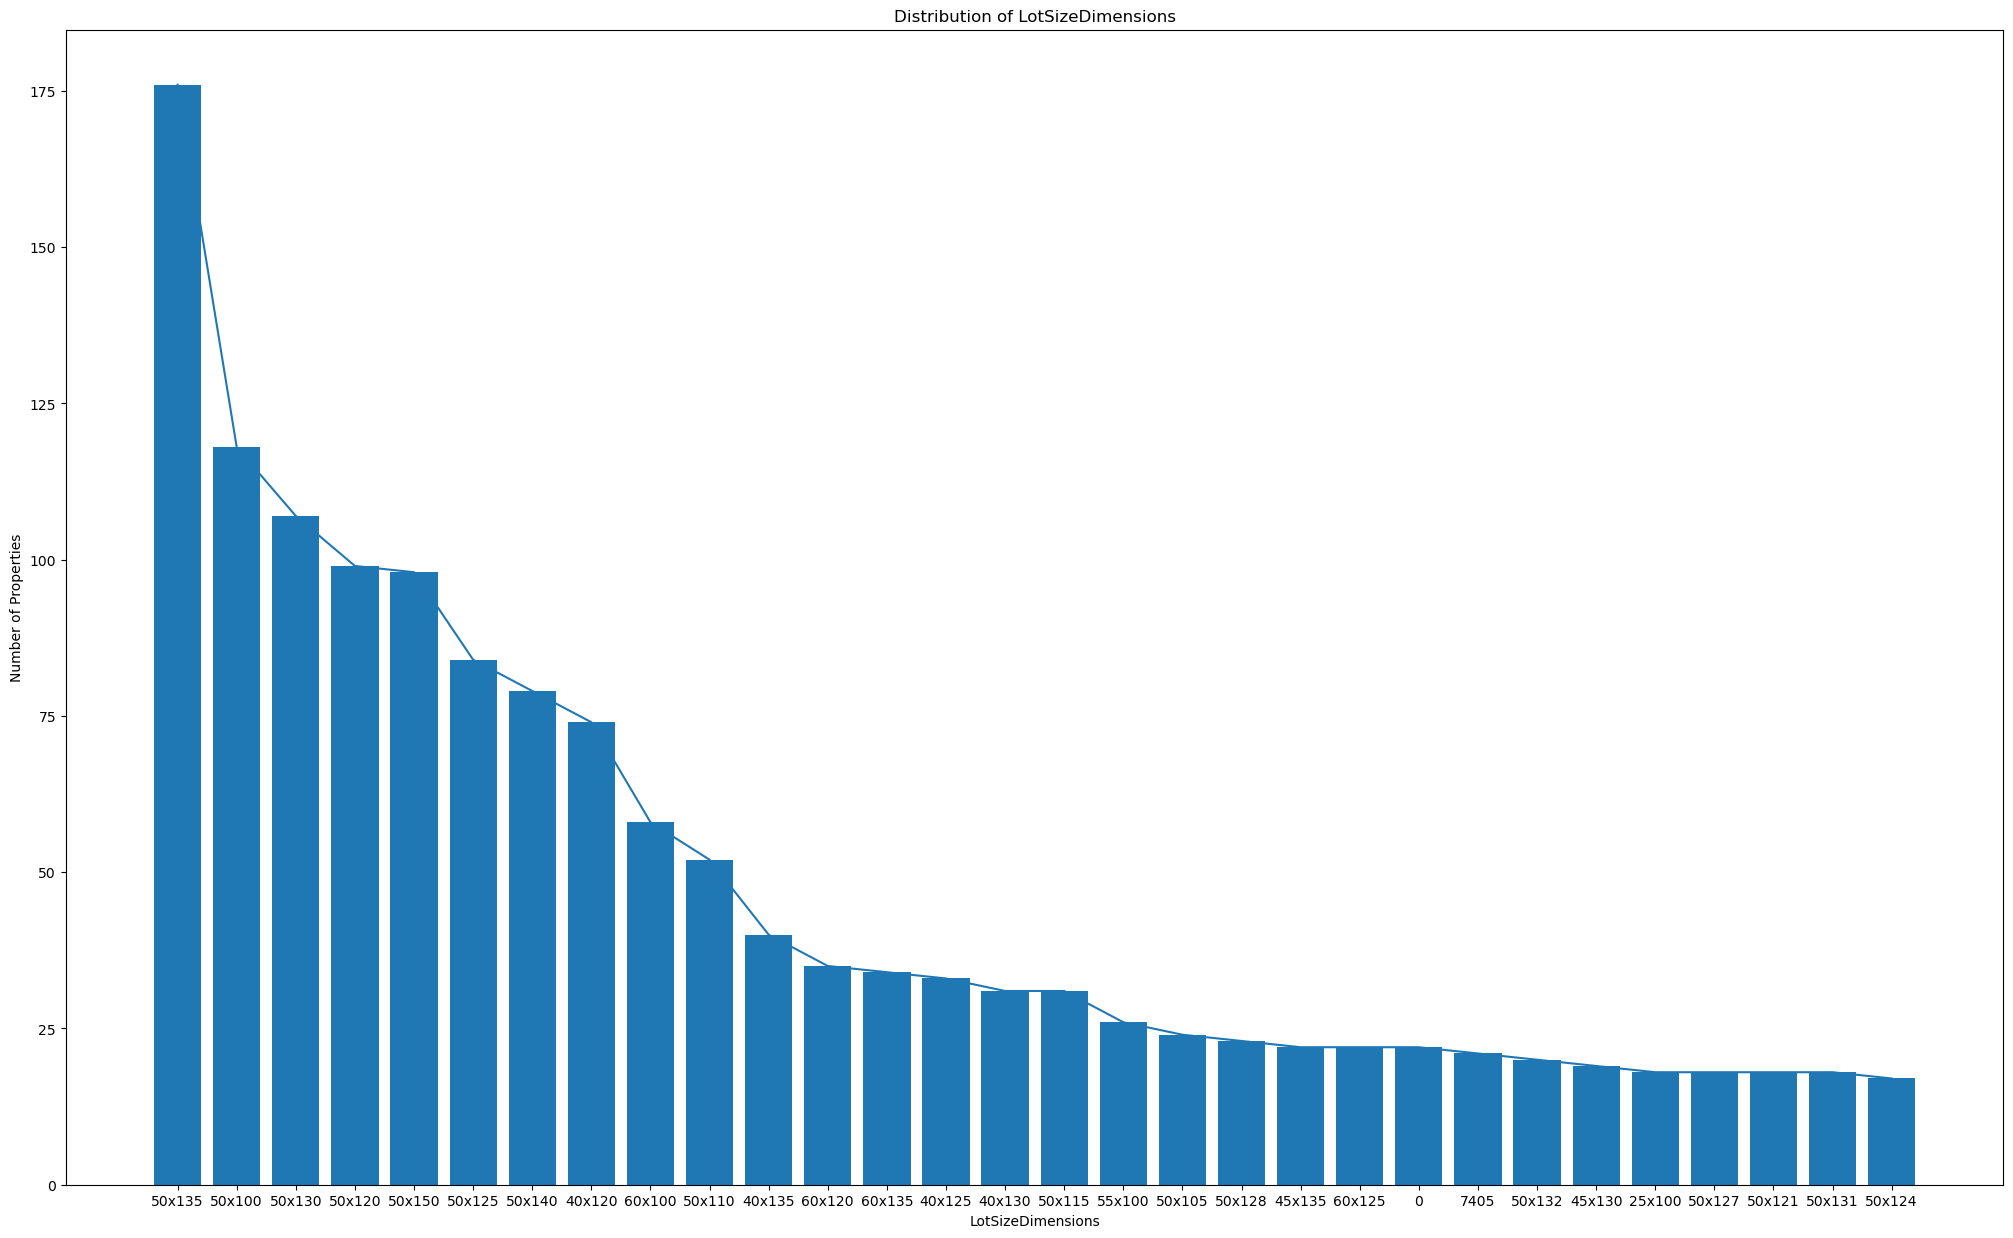

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.plot(dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30))
plt.bar(dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30).index,dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30).values)
plt.xlabel("LotSizeDimensions")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeDimensions")
plt.show()

LotSizeSquareFeet: The total square footage of the lot. This field is related to the Lot Size Area and Lot Size Units and must be in sync with the values represented in those fields. Lot Size Source also applies to this field when used.

In [62]:
dataset_total_last6_r["LotSizeSquareFeet"].value_counts()

LotSizeSquareFeet
0.0         3396
7405.0      2773
6000.0      2080
6534.0      1795
6098.0      1771
            ... 
103562.0       1
19533.0        1
12214.0        1
43141.0        1
30457.0        1
Name: count, Length: 30204, dtype: int64

In [63]:
dataset_total_last6_r["LotSizeSquareFeet"].describe()

count    1.755970e+05
mean     4.110035e+05
std      1.812073e+07
min      0.000000e+00
25%      5.300000e+03
50%      7.365000e+03
75%      1.249400e+04
max      1.945128e+09
Name: LotSizeSquareFeet, dtype: float64

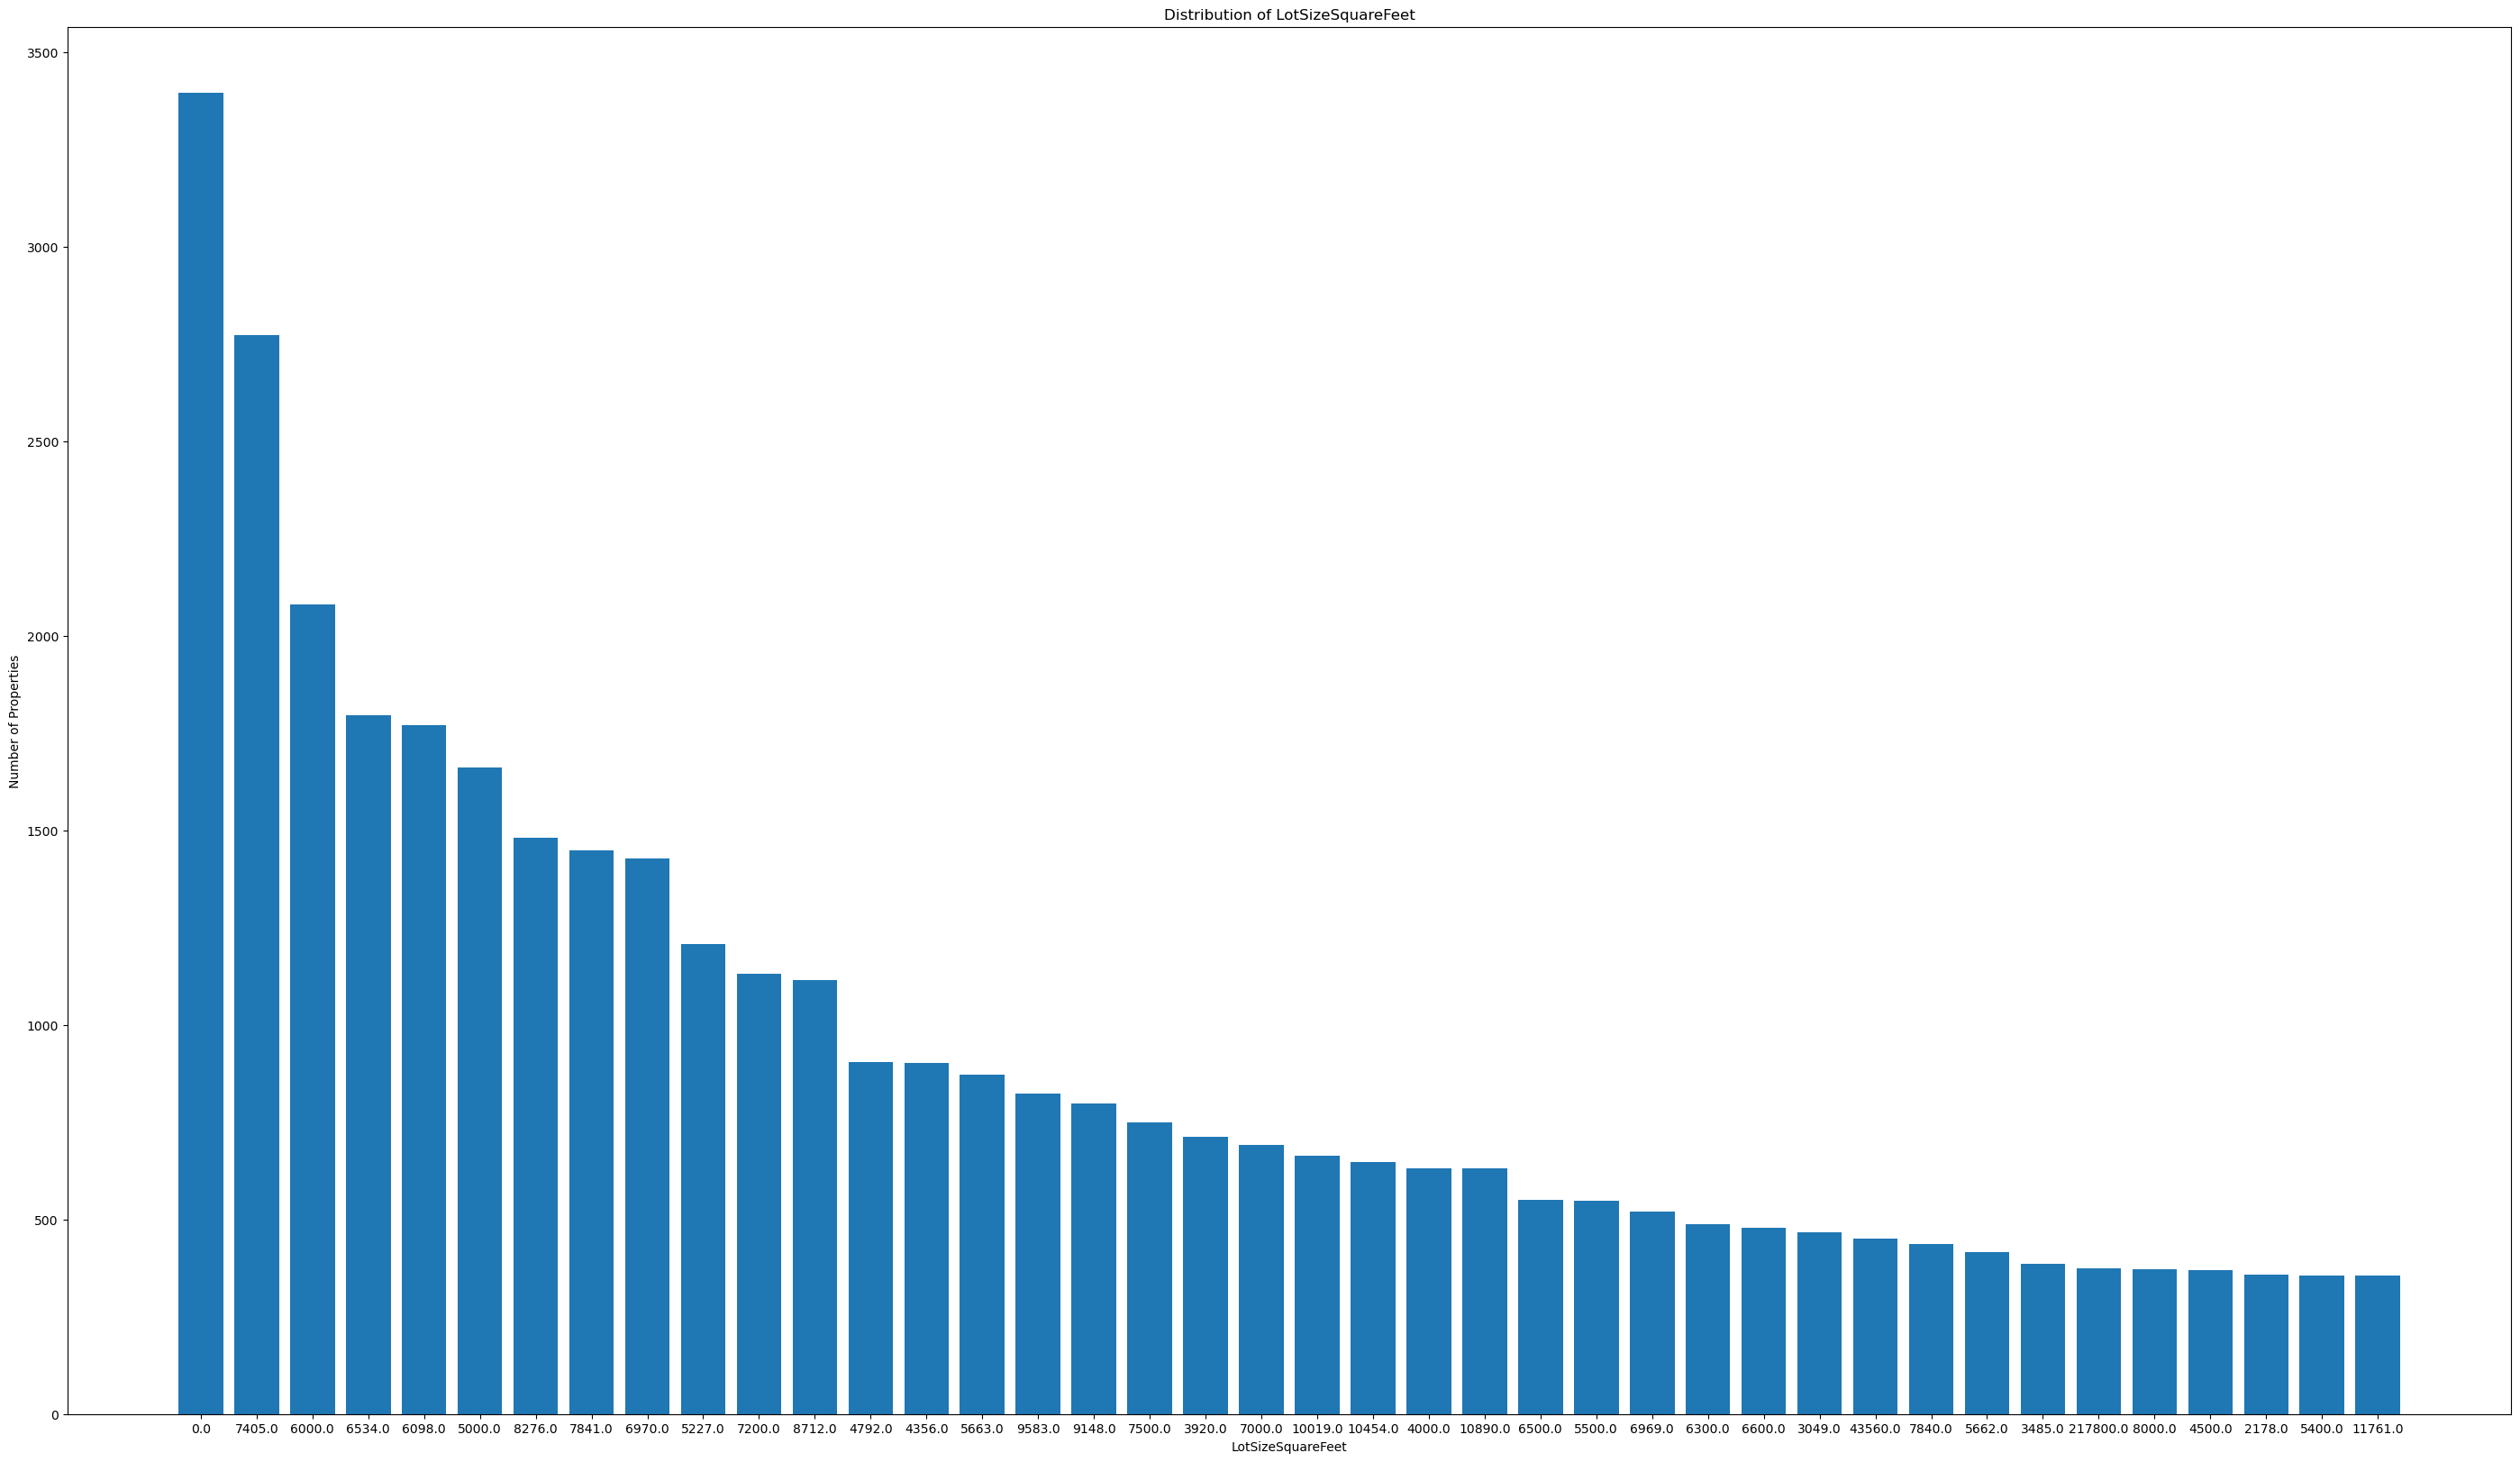

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(35, 20))
plt.bar(dataset_total_last6_r["LotSizeSquareFeet"].value_counts().head(40).index.astype(str),dataset_total_last6_r["LotSizeSquareFeet"].value_counts().head(40).values)
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeSquareFeet")
plt.show()

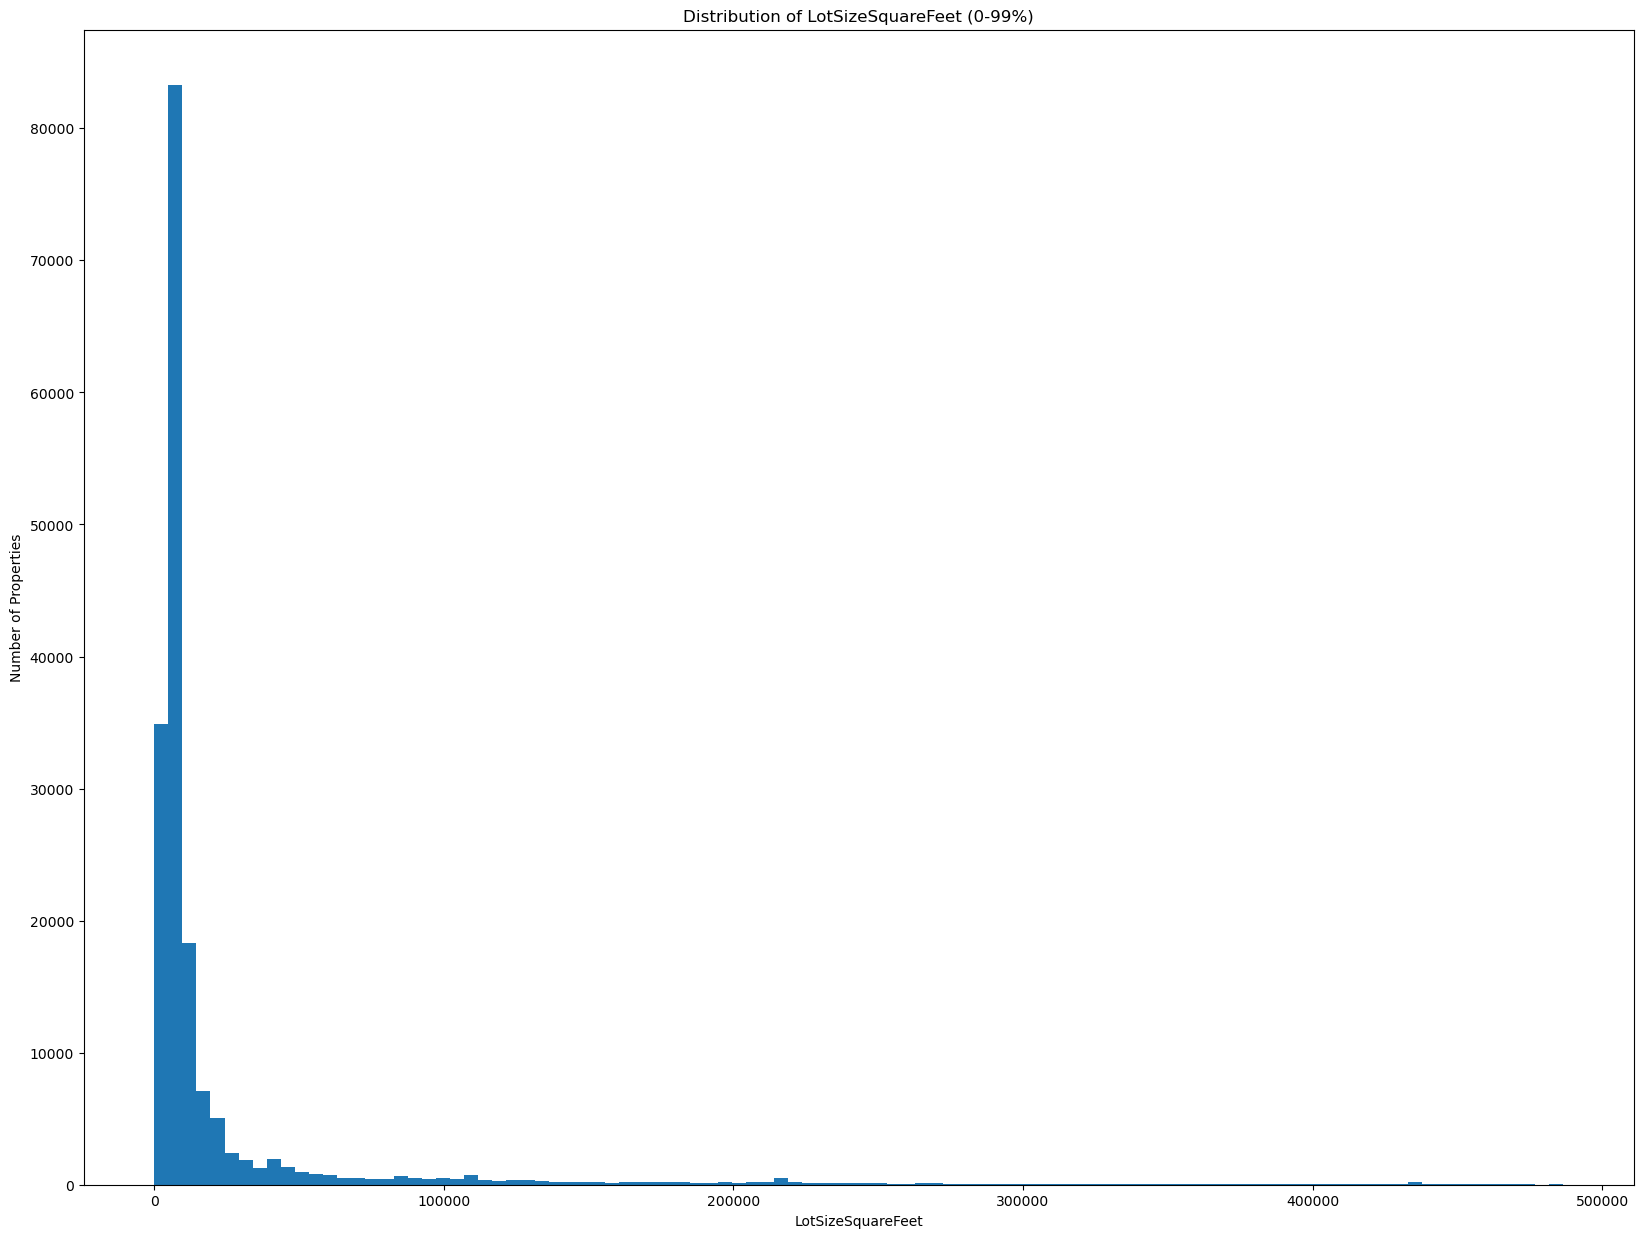

In [65]:
upper = dataset_total_last6_r["LotSizeSquareFeet"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["LotSizeSquareFeet"] <= upper]["LotSizeSquareFeet"]
plt.figure(figsize=(20,15))
plt.hist(data, bins=100)
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeSquareFeet (0-99%)")
plt.show()

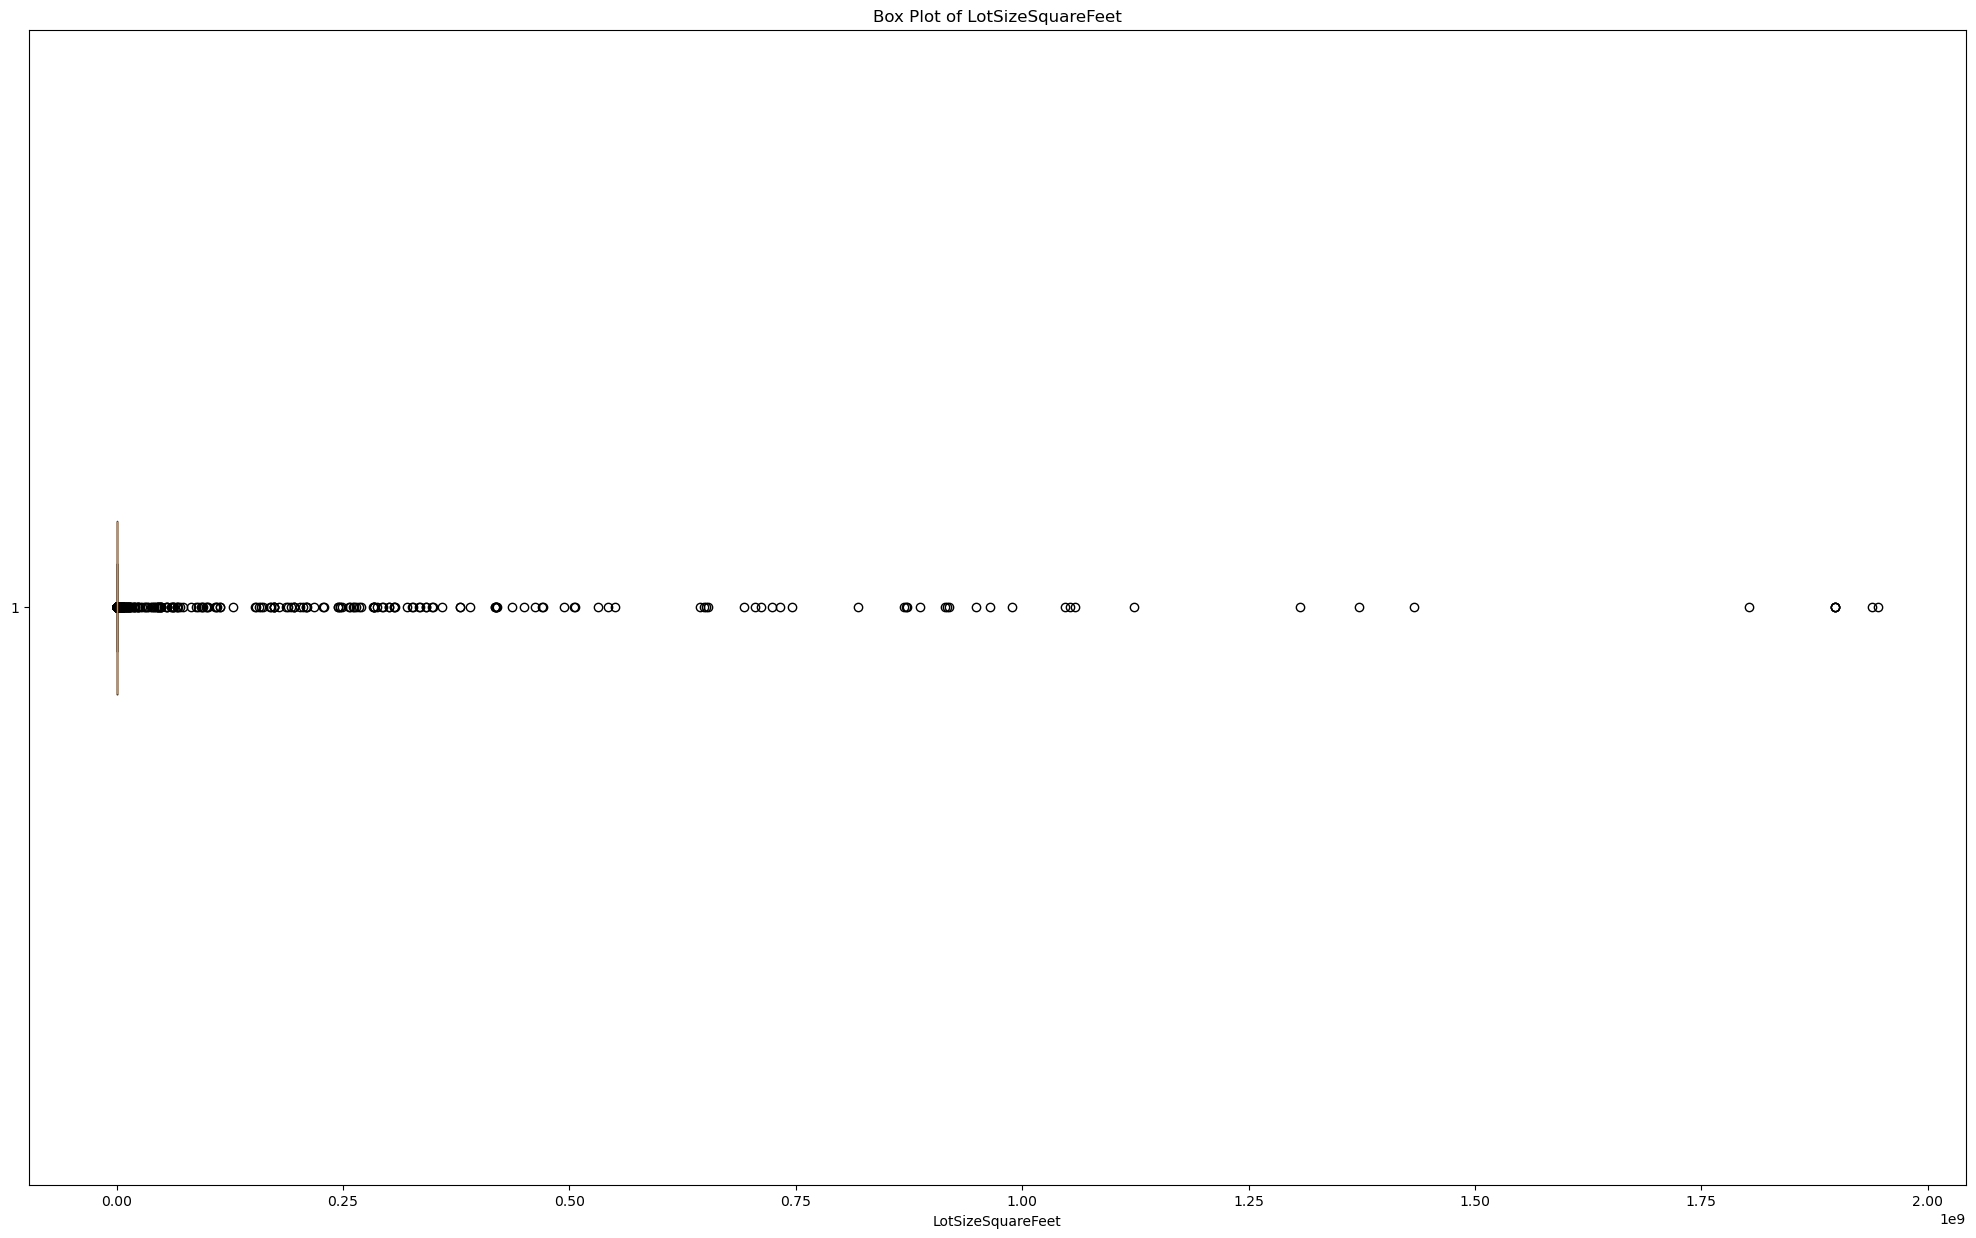

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.boxplot(dataset_total_last6_r["LotSizeSquareFeet"].dropna(), vert=False)

plt.title("Box Plot of LotSizeSquareFeet")
plt.xlabel("LotSizeSquareFeet")
plt.show()

## Correlation Analysis

ClosePrice shows weak positive correlations with LivingArea (0.11), BathroomsTotalInteger (0.09), and BedroomsTotal (0.06), while LotSizeSquareFeet has almost no linear correlation with ClosePrice. This suggests that these individual features alone are not strong predictors of house prices, and other factors may also play important roles.

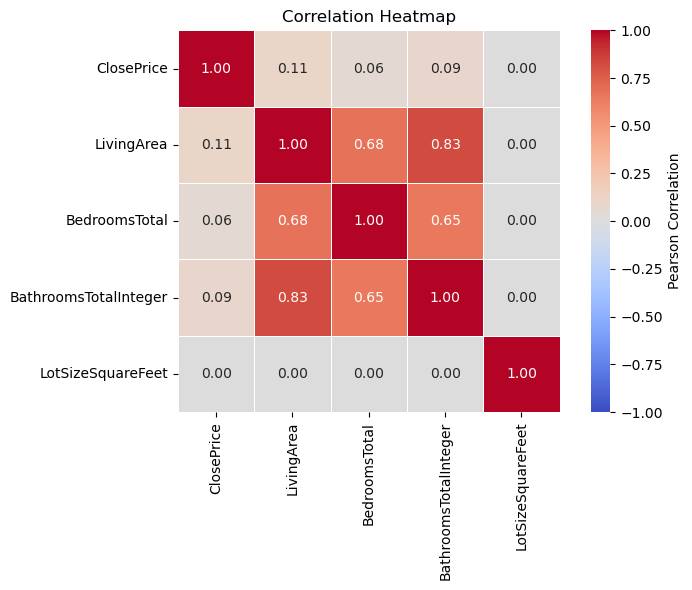

In [68]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = dataset_total_last6_r.copy()

df["LivingArea"] = df["LivingArea"].replace(0, np.nan)
df["LotSizeSquareFeet"] = df["LotSizeSquareFeet"].replace(0, np.nan)

cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

corr = df[cols].dropna().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,          fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1,center=0,square=True,linewidths=0.5,cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()